# Machine Learning: Basics to Expert

A single, self-contained course on **machine learning itself** — the ideas, the math, and the algorithms,
each one **implemented from scratch in NumPy** and then checked against scikit-learn.
(For the scikit-learn *library* tour, see `sklearn_basics_to_expert.ipynb` in this series.)

**How to read this notebook:** every section builds one idea, shows the math, codes it from first principles,
and ends with the production-grade equivalent. Run cells top to bottom.

### Contents
| Part | Sections |
|---|---|
| **I — Foundations** | [1. What is machine learning?](#1) · [2. Data, generalization & the golden rule](#2) · [3. First model from scratch: k-NN](#3) · [4. Loss functions](#4) |
| **II — Linear models & core theory** | [5. Linear regression: closed form](#5) · [6. Gradient descent](#6) · [7. Logistic regression](#7) · [8. Overfitting & regularization](#8) · [9. Bias–variance tradeoff](#9) |
| **III — Evaluation** | [10. Classification metrics from scratch](#10) · [11. Cross-validation & leakage](#11) |
| **IV — Nonlinear models** | [12. Decision trees from scratch](#12) · [13. Bagging & random forests](#13) · [14. Gradient boosting](#14) · [15. SVMs & the kernel trick](#15) · [16. Neural networks & backprop from scratch](#16) |
| **V — Unsupervised learning** | [17. k-means from scratch](#17) · [18. PCA from scratch](#18) |
| **VI — Expert practice** | [19. Learning & validation curves](#19) · [20. Hyperparameter tuning](#20) · [21. Imbalanced data & calibration](#21) · [22. Capstone: end-to-end project](#22) · [23. Model interpretation](#23) · [24. Where to go from here](#24) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import sklearn

print("numpy:", np.__version__, "| pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

# One fixed, colorblind-safe categorical palette used throughout the notebook
# (assigned in this fixed order, never re-shuffled per chart).
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
GRAY = "#898781"

plt.rcParams.update({
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e", "axes.titlecolor": "#0b0b0b",
    "xtick.color": GRAY, "ytick.color": GRAY,
    "figure.dpi": 100, "figure.facecolor": "white",
})

rng = np.random.default_rng(42)   # one seeded generator for the whole notebook

numpy: 2.3.1 | pandas: 2.3.0 | scikit-learn: 1.7.2


<a id="1"></a>
## 1. What is machine learning?

Classical programming: you write the **rules**, the computer applies them to data.
Machine learning inverts this: you show the computer **data + answers**, and it finds the rules.

$$\text{rules} + \text{data} \xrightarrow{\text{programming}} \text{answers}
\qquad\qquad
\text{data} + \text{answers} \xrightarrow{\text{learning}} \text{rules}$$

Three broad families:

| Family | You provide | The model learns | Examples |
|---|---|---|---|
| **Supervised** | inputs $X$ **and** targets $y$ | a mapping $f: X \to y$ | spam filter, price prediction |
| **Unsupervised** | inputs $X$ only | structure in the data | clustering, compression |
| **Reinforcement** | an environment + rewards | a decision policy | game playing, robotics |

Supervised learning splits again by target type: **regression** (continuous $y$) and **classification** (discrete $y$).
This notebook covers supervised and unsupervised learning; reinforcement learning is its own field.

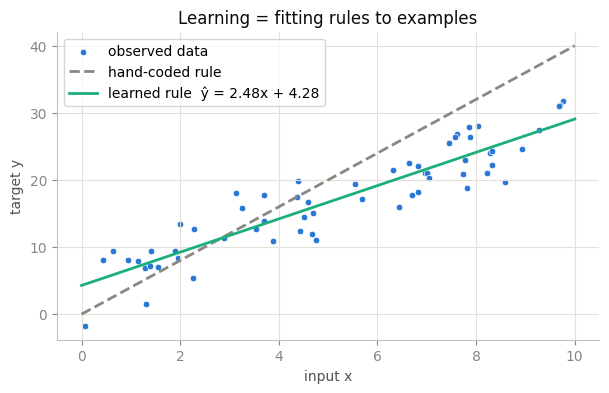

In [2]:
# The core idea in one picture: instead of hand-coding a rule, fit one from examples.
x = rng.uniform(0, 10, 60)
y = 2.5 * x + 5 + rng.normal(0, 4, 60)          # the "world" (unknown to us)

hand_rule = lambda x: 4 * x                      # a rule someone guessed by eye
w, b = np.polyfit(x, y, 1)                       # a rule *learned* from the data

xs = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=22, color=PALETTE[0], edgecolor="white", linewidth=0.5, label="observed data")
ax.plot(xs, hand_rule(xs), color=GRAY, ls="--", lw=2, label="hand-coded rule")
ax.plot(xs, w * xs + b, color=PALETTE[1], lw=2, label=f"learned rule  ŷ = {w:.2f}x + {b:.2f}")
ax.set_xlabel("input x"); ax.set_ylabel("target y")
ax.set_title("Learning = fitting rules to examples")
ax.legend()
plt.show()

<a id="2"></a>
## 2. Data, generalization, and the golden rule

In supervised learning the data is a matrix $X$ of shape `(n_samples, n_features)` and a target
vector $y$ of length `n_samples`. Each row is one **example**; each column is one **feature**.

The goal is **not** to do well on the data you have — it is to do well on data you *haven't seen*.
That property is called **generalization**, and it forces the golden rule:

> **Never evaluate a model on data it was trained on.**

A model can score 100% on its training data simply by *memorizing* it. The demonstration below uses
1-nearest-neighbor, the purest memorizer there is: to predict a point, it looks up the most similar
training example and copies its label.

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X, y = make_classification(n_samples=400, n_features=10, n_informative=4,
                           flip_y=0.15, random_state=42)   # 15% label noise: memorizing it is a trap

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

memorizer = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
print(f"train accuracy: {memorizer.score(X_train, y_train):.3f}   <- perfect: it just memorized")
print(f"test  accuracy: {memorizer.score(X_test,  y_test):.3f}   <- reality")

train accuracy: 1.000   <- perfect: it just memorized
test  accuracy: 0.780   <- reality


The gap between those two numbers is the whole reason machine learning methodology exists.
Everything in this notebook — train/test splits, cross-validation, regularization, the bias–variance
tradeoff — is machinery for closing or honestly measuring that gap.

**Vocabulary you now own:** *training set* (fit the model), *test set* (estimate generalization,
touched once at the very end), and later a *validation set* (compare models and tune knobs).

<a id="3"></a>
## 3. Your first model from scratch: k-nearest neighbors

k-NN is the simplest model that actually works, and it needs no training at all:

1. To classify a new point, compute its distance to **every** training point.
2. Take the $k$ closest ones.
3. Predict the **majority class** among them.

The only math is Euclidean distance, $\lVert a-b \rVert_2 = \sqrt{\sum_j (a_j - b_j)^2}$.
Ten lines of NumPy:

In [4]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=300, centers=3, cluster_std=2.6, random_state=7)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=0)

def knn_predict(X_train, y_train, X_new, k=5):
    # pairwise distances, shape (n_new, n_train), via broadcasting
    d = np.linalg.norm(X_new[:, None, :] - X_train[None, :, :], axis=2)
    nearest = np.argsort(d, axis=1)[:, :k]          # indices of the k closest
    votes = y_train[nearest]                        # their labels
    return np.array([np.bincount(v).argmax() for v in votes])

ours = knn_predict(Xb_tr, yb_tr, Xb_te, k=5)
print(f"our k-NN accuracy:      {(ours == yb_te).mean():.3f}")

sk = KNeighborsClassifier(n_neighbors=5).fit(Xb_tr, yb_tr)
print(f"sklearn k-NN accuracy:  {sk.score(Xb_te, yb_te):.3f}")
print(f"identical predictions:  {(ours == sk.predict(Xb_te)).all()}")

our k-NN accuracy:      0.944
sklearn k-NN accuracy:  0.944
identical predictions:  True


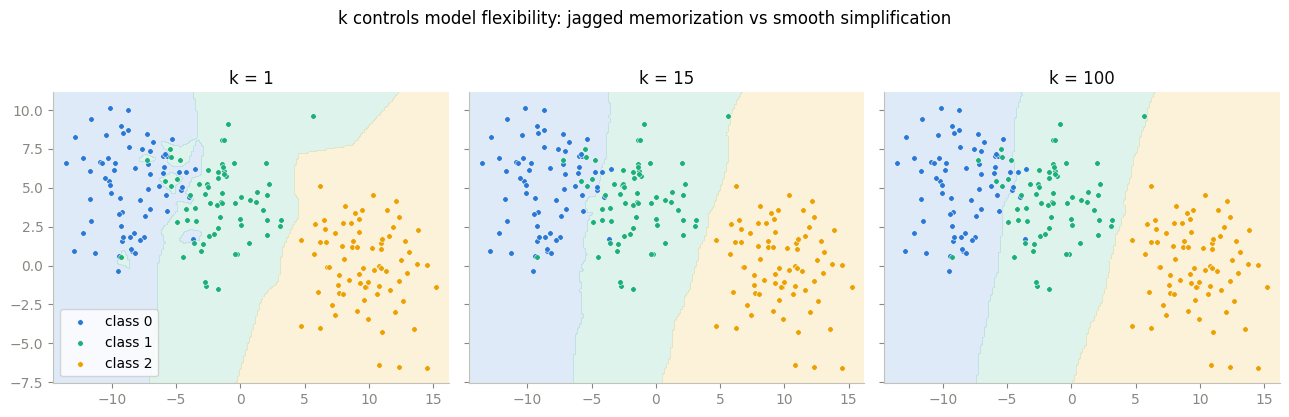

In [5]:
# A reusable helper we'll use all notebook long: paint a model's decision regions.
from matplotlib.colors import ListedColormap

def plot_regions(predict, X, y, ax, title="", res=200):
    """predict: function mapping (n,2) array -> (n,) class labels."""
    x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, res)
    x1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, res)
    xx, yy = np.meshgrid(x0, x1)
    Z = predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    k = len(np.unique(y))
    cmap = ListedColormap(PALETTE[:k])
    ax.contourf(xx, yy, Z, alpha=0.15, cmap=cmap, levels=np.arange(k + 1) - 0.5)
    for c in range(k):
        m = y == c
        ax.scatter(X[m, 0], X[m, 1], s=16, color=PALETTE[c],
                   edgecolor="white", linewidth=0.4, label=f"class {c}")
    ax.set_title(title); ax.grid(False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, k in zip(axes, [1, 15, 100]):
    plot_regions(lambda G, k=k: knn_predict(Xb_tr, yb_tr, G, k=k), Xb_tr, yb_tr, ax,
                 title=f"k = {k}")
axes[0].legend(loc="lower left")
fig.suptitle("k controls model flexibility: jagged memorization vs smooth simplification", y=1.03)
plt.tight_layout(); plt.show()

Look at the three panels: **k = 1** carves a private island around every noisy point (overfitting),
**k = 100** steamrolls real structure (underfitting), and **k = 15** balances the two. Almost every model
you'll ever use has a knob like this — a **hyperparameter** trading flexibility against stability.
Section 9 makes this tradeoff precise.

**Gotchas that matter in practice:** k-NN needs features on comparable scales (a feature measured in
millimeters will drown one measured in meters — always standardize), and it gets slow and unreliable
in high dimensions (the *curse of dimensionality*: in 100-D, everything is far from everything).

<a id="4"></a>
## 4. Loss functions: how models know they're wrong

k-NN has no notion of "how wrong am I?". Every model from here on does, via a **loss function**
$\ell(y, \hat y)$ — a number that is small when the prediction is good. Training is then an optimization:

$$\min_\theta \; \frac{1}{n}\sum_{i=1}^n \ell\big(y_i, f_\theta(x_i)\big)
\qquad \text{(empirical risk minimization)}$$

The choice of loss encodes what you care about:

| Task | Loss | Formula | Character |
|---|---|---|---|
| Regression | Squared (MSE) | $(y-\hat y)^2$ | punishes big errors hard; sensitive to outliers |
| Regression | Absolute (MAE) | $\lvert y-\hat y\rvert$ | robust to outliers; median-seeking |
| Regression | Huber | quadratic near 0, linear far | best of both |
| Classification | 0–1 | $\mathbf{1}[y \ne \hat y]$ | what you want, but flat ⇒ un-optimizable |
| Classification | Log loss | $\log(1+e^{-m})$ | smooth surrogate; $m = y\cdot f(x)$ is the *margin* |
| Classification | Hinge | $\max(0, 1-m)$ | the SVM loss; ignores confidently-correct points |

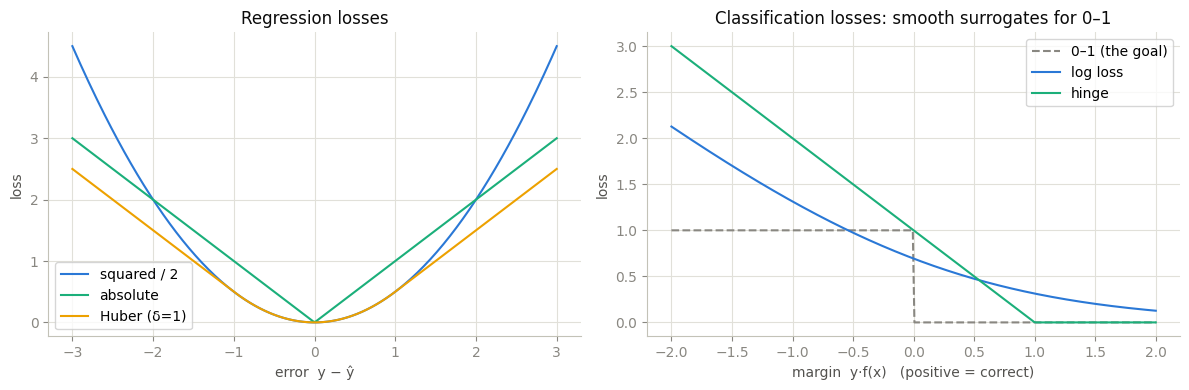

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

e = np.linspace(-3, 3, 300)                       # regression: error y - yhat
delta = 1.0
huber = np.where(np.abs(e) <= delta, 0.5 * e**2, delta * (np.abs(e) - 0.5 * delta))
ax1.plot(e, e**2 / 2, label="squared / 2")
ax1.plot(e, np.abs(e), label="absolute")
ax1.plot(e, huber, label="Huber (δ=1)")
ax1.set_xlabel("error  y − ŷ"); ax1.set_ylabel("loss")
ax1.set_title("Regression losses"); ax1.legend()

m = np.linspace(-2, 2, 300)                       # classification: margin y·f(x)
ax2.plot(m, (m < 0).astype(float), label="0–1 (the goal)", color=GRAY, ls="--")
ax2.plot(m, np.log1p(np.exp(-m)), label="log loss", color=PALETTE[0])
ax2.plot(m, np.maximum(0, 1 - m), label="hinge", color=PALETTE[1])
ax2.set_xlabel("margin  y·f(x)   (positive = correct)"); ax2.set_ylabel("loss")
ax2.set_title("Classification losses: smooth surrogates for 0–1")
ax2.legend()
plt.tight_layout(); plt.show()

**Why surrogates?** The 0–1 loss (dashed) is what we truly want, but it's flat almost everywhere —
its gradient is zero, so gradient-based optimization can't move. Log loss and hinge are smooth (or at
least convex) upper bounds that *can* be optimized and provably push 0–1 error down too. This
pattern — optimize a tractable surrogate for an intractable goal — is one of ML's deepest tricks.

<a id="5"></a>
## 5. Linear regression I: the closed-form solution

The simplest parametric model: predictions are a weighted sum of features,
$\hat y = \theta_0 + \theta_1 x_1 + \dots + \theta_d x_d$. Stack a column of ones onto $X$ so the
intercept is just another weight, and the MSE loss becomes

$$J(\theta) = \frac{1}{n}\lVert X\theta - y\rVert^2 .$$

This is a smooth bowl in $\theta$; setting its gradient to zero gives the **normal equations**:

$$\nabla J = \tfrac{2}{n} X^\top (X\theta - y) = 0
\;\;\Longrightarrow\;\;
X^\top X \,\theta = X^\top y .$$

One linear solve and training is *done* — no iteration, no learning rate.

learned:  intercept = 4.809, slope = 2.566
sklearn:  intercept = 4.809, slope = 2.566


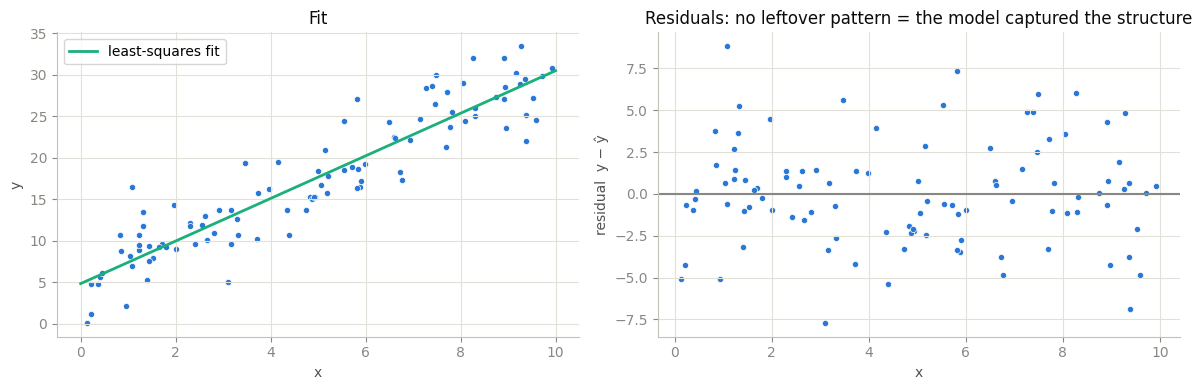

In [7]:
n = 100
x = rng.uniform(0, 10, n)
y = 2.5 * x + 5 + rng.normal(0, 3, n)             # ground truth: slope 2.5, intercept 5

X_design = np.c_[np.ones(n), x]                   # prepend the bias column
theta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)
print(f"learned:  intercept = {theta[0]:.3f}, slope = {theta[1]:.3f}")

from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"sklearn:  intercept = {lr.intercept_:.3f}, slope = {lr.coef_[0]:.3f}")

resid = y - X_design @ theta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
xs = np.linspace(0, 10, 50)
ax1.scatter(x, y, s=20, color=PALETTE[0], edgecolor="white", linewidth=0.5)
ax1.plot(xs, theta[0] + theta[1] * xs, color=PALETTE[1], lw=2, label="least-squares fit")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_title("Fit"); ax1.legend()
ax2.scatter(x, resid, s=20, color=PALETTE[0], edgecolor="white", linewidth=0.5)
ax2.axhline(0, color=GRAY, lw=1.5)
ax2.set_xlabel("x"); ax2.set_ylabel("residual  y − ŷ")
ax2.set_title("Residuals: no leftover pattern = the model captured the structure")
plt.tight_layout(); plt.show()

**Always look at residuals.** If they show a curve, a funnel, or clusters, the linear model is missing
something — add features, transform, or move to a nonlinear model.

**Why not always use the closed form?** $X^\top X$ is $d\times d$; solving costs $O(d^3)$ and it must fit in
memory. With millions of features, or losses *other than MSE* (which have no closed form at all),
we need an iterative method. Enter gradient descent.

<a id="6"></a>
## 6. Linear regression II: gradient descent

Gradient descent is *the* workhorse of modern ML (all deep learning runs on its variants). The idea:
the gradient $\nabla J(\theta)$ points uphill, so take a small step downhill, repeatedly:

$$\theta \leftarrow \theta - \eta\, \nabla J(\theta)$$

The step size $\eta$ (**learning rate**) is the most important hyperparameter in all of ML:

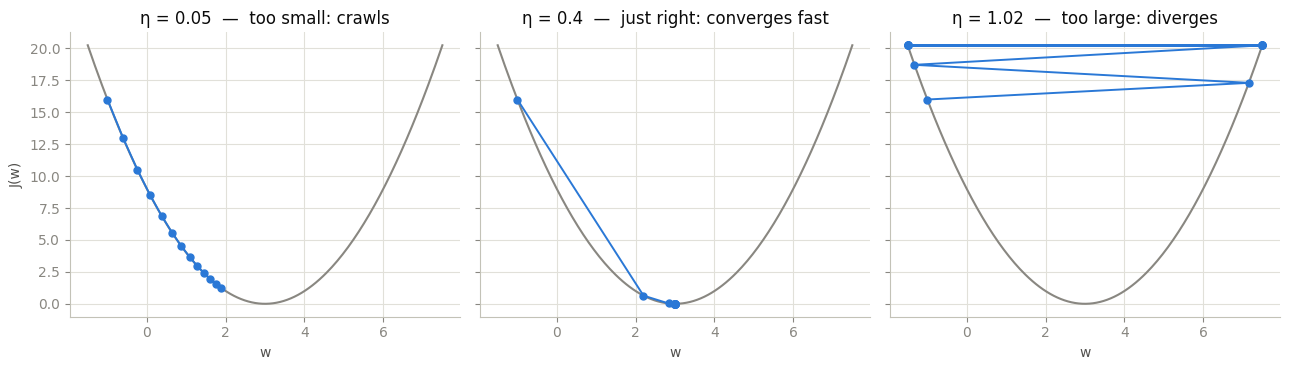

In [8]:
# Anatomy of the learning rate on the simplest possible loss: J(w) = (w - 3)^2
J  = lambda w: (w - 3) ** 2
dJ = lambda w: 2 * (w - 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
ws = np.linspace(-1.5, 7.5, 200)
for ax, eta, verdict in zip(axes, [0.05, 0.4, 1.02],
                            ["too small: crawls", "just right: converges fast", "too large: diverges"]):
    ax.plot(ws, J(ws), color=GRAY, lw=1.5)
    w, path = -1.0, [-1.0]
    for _ in range(12):
        w = w - eta * dJ(w)
        path.append(w)
    path = np.clip(np.array(path), -1.5, 7.5)
    ax.plot(path, J(path), "o-", color=PALETTE[0], ms=5, lw=1.4)
    ax.set_title(f"η = {eta}  —  {verdict}")
    ax.set_xlabel("w")
axes[0].set_ylabel("J(w)")
plt.tight_layout(); plt.show()

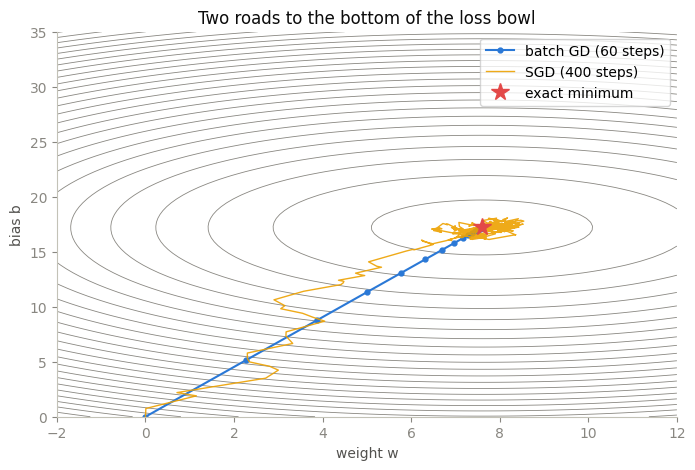

exact: w=7.598 b=17.206 | batch GD: w=7.598 b=17.206 | SGD: w=7.598 b=17.108


In [9]:
# Now the real thing: gradient descent for linear regression, vs. the exact solution.
# Standardize x first — GD converges far faster on scaled features.
x_s = (x - x.mean()) / x.std()
y_c = y

def loss_wb(W, B):                                # MSE surface over (w, b), vectorized
    return ((W[..., None] * x_s[None, None, :] + B[..., None] - y_c) ** 2).mean(-1) / 2

def grad_wb(w, b, xi=x_s, yi=y_c):
    err = w * xi + b - yi
    return (err * xi).mean(), err.mean()

# --- batch gradient descent: uses ALL n points per step
w = b = 0.0; batch_path = [(w, b)]
for _ in range(60):
    gw, gb = grad_wb(w, b)
    w, b = w - 0.3 * gw, b - 0.3 * gb
    batch_path.append((w, b))

# --- stochastic gradient descent: ONE random point per step (cheap, noisy)
w2 = b2 = 0.0; sgd_path = [(w2, b2)]
for i in rng.integers(0, n, 400):
    gw, gb = grad_wb(w2, b2, x_s[i:i+1], y_c[i:i+1])
    w2, b2 = w2 - 0.05 * gw, b2 - 0.05 * gb
    sgd_path.append((w2, b2))

W, B = np.meshgrid(np.linspace(-2, 12, 100), np.linspace(0, 35, 100))
fig, ax = plt.subplots(figsize=(8, 5))
cs = ax.contour(W, B, loss_wb(W, B), levels=25, colors=GRAY, linewidths=0.6)
bp, sp = np.array(batch_path), np.array(sgd_path)
ax.plot(bp[:, 0], bp[:, 1], "o-", color=PALETTE[0], ms=3.5, lw=1.5, label="batch GD (60 steps)")
ax.plot(sp[:, 0], sp[:, 1], "-", color=PALETTE[2], lw=1, alpha=0.9, label="SGD (400 steps)")
theta_exact = np.linalg.lstsq(np.c_[x_s, np.ones(n)], y_c, rcond=None)[0]
ax.plot(*theta_exact, "*", color=PALETTE[5], ms=13, label="exact minimum")
ax.set_xlabel("weight w"); ax.set_ylabel("bias b"); ax.grid(False)
ax.set_title("Two roads to the bottom of the loss bowl")
ax.legend()
plt.show()
print(f"exact: w={theta_exact[0]:.3f} b={theta_exact[1]:.3f} | batch GD: w={w:.3f} b={b:.3f} | SGD: w={w2:.3f} b={b2:.3f}")

**Batch GD** walks smoothly downhill but touches every sample per step — expensive at scale.
**SGD** staggers drunkenly yet reaches the same neighborhood using single samples — this scalability
is why it (in mini-batch form, e.g. 32–512 samples per step) powers all of deep learning. The residual
jitter around the minimum is tamed by decaying the learning rate over time.

Three practical rules that carry to every model you'll ever train:
1. **Scale your features** — unscaled features make the bowl a narrow canyon and GD zig-zags painfully.
2. **Tune the learning rate first** — it matters more than any other knob.
3. **Watch the training loss curve** — flat = η too small; exploding = η too large.

<a id="7"></a>
## 7. Logistic regression: classification with probabilities

To classify, we want $P(y{=}1 \mid x)$. Take the linear score $z = \theta^\top x$ and squash it
into $(0,1)$ with the **sigmoid** $\sigma(z) = \frac{1}{1+e^{-z}}$. Training minimizes **log loss**
(binary cross-entropy):

$$J(\theta) = -\frac1n \sum_i \Big[\, y_i \log p_i + (1-y_i)\log(1-p_i) \,\Big],
\qquad p_i = \sigma(\theta^\top x_i)$$

The gradient turns out to be astonishingly clean — *identical in form* to linear regression's:

$$\nabla J = \frac1n X^\top (p - y)$$

our accuracy: 0.967 | sklearn accuracy: 0.967


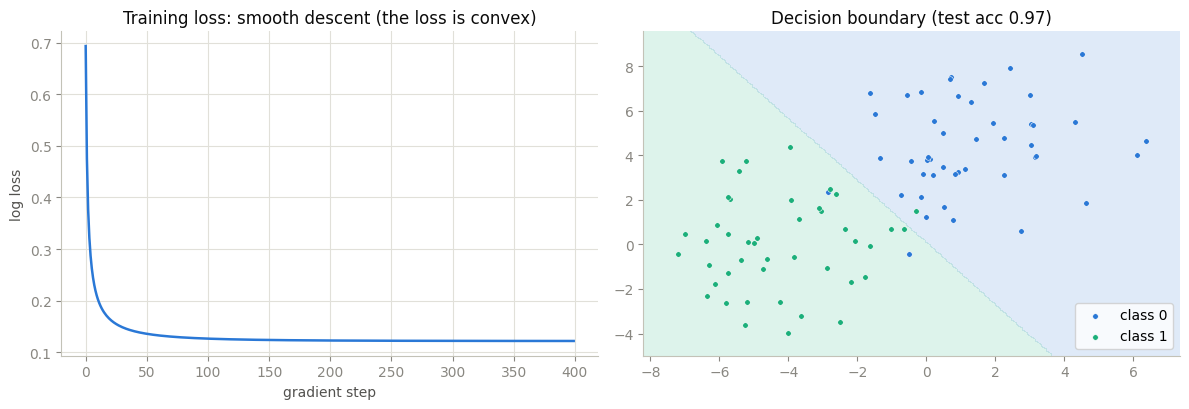

In [10]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))

X2, y2 = make_blobs(n_samples=300, centers=2, cluster_std=1.9, random_state=3)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=0)

def train_logreg(X, y, eta=0.1, iters=400):
    Xd = np.c_[np.ones(len(X)), X]
    theta = np.zeros(Xd.shape[1])
    losses = []
    for _ in range(iters):
        p = sigmoid(Xd @ theta)
        losses.append(-(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)).mean())
        theta -= eta * Xd.T @ (p - y) / len(y)
    return theta, losses

theta_lr, losses = train_logreg(X2_tr, y2_tr)
predict_scratch = lambda G: (sigmoid(np.c_[np.ones(len(G)), G] @ theta_lr) >= 0.5).astype(int)
acc = (predict_scratch(X2_te) == y2_te).mean()

from sklearn.linear_model import LogisticRegression
sk_lr = LogisticRegression().fit(X2_tr, y2_tr)
print(f"our accuracy: {acc:.3f} | sklearn accuracy: {sk_lr.score(X2_te, y2_te):.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(losses, color=PALETTE[0], lw=1.8)
ax1.set_xlabel("gradient step"); ax1.set_ylabel("log loss")
ax1.set_title("Training loss: smooth descent (the loss is convex)")
plot_regions(predict_scratch, X2_te, y2_te, ax2, title=f"Decision boundary (test acc {acc:.2f})")
ax2.legend(loc="lower right")
plt.tight_layout(); plt.show()

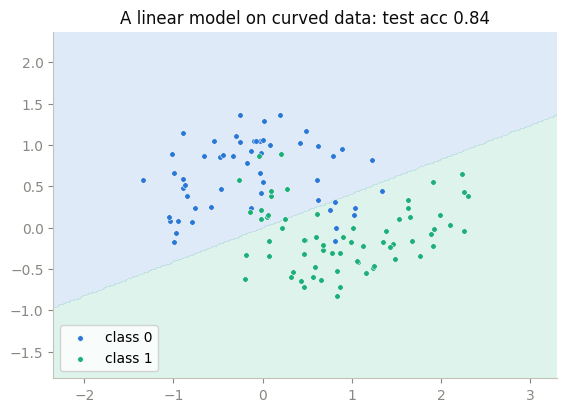

In [11]:
# The boundary is a straight line: sigma(z) >= 0.5  <=>  z >= 0, and z is linear in x.
# Linear boundaries fail when the truth is curved:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=400, noise=0.25, random_state=1)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0)

theta_m, _ = train_logreg(Xm_tr, ym_tr, iters=800)
pred_m = lambda G: (sigmoid(np.c_[np.ones(len(G)), G] @ theta_m) >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_regions(pred_m, Xm_te, ym_te, ax,
             title=f"A linear model on curved data: test acc {(pred_m(Xm_te)==ym_te).mean():.2f}")
ax.legend(loc="lower left")
plt.show()

~85% is the ceiling for *any* straight line on this data. Two escape routes, and the rest of the
notebook explores both:
- **Engineer nonlinear features** by hand ($x^2$, $x_1 x_2$, …) and keep the linear machinery → section 8.
- **Use models that learn nonlinearity themselves** — trees, kernels, neural nets → sections 12–16.

**Gotcha:** logistic regression outputs *probabilities*, and well-calibrated ones at that (a predicted
0.8 really does come true ~80% of the time). Many fancier models can't say the same — see section 21.

<a id="8"></a>
## 8. Overfitting and regularization

Give a linear model enough derived features (e.g. polynomial powers $x, x^2, \dots, x^{15}$) and it can
wiggle through every training point — fitting the *noise*, not the signal. **Regularization** fights back
by adding a penalty on weight size to the loss:

$$J(\theta) = \text{MSE} + \alpha \sum_j \theta_j^2 \;\;\text{(ridge / L2)}
\qquad
J(\theta) = \text{MSE} + \alpha \sum_j |\theta_j| \;\;\text{(lasso / L1)}$$

Large weights are what allow wild wiggles, so penalizing them trades a bit of training fit for a lot
of stability. $\alpha$ sets the exchange rate.

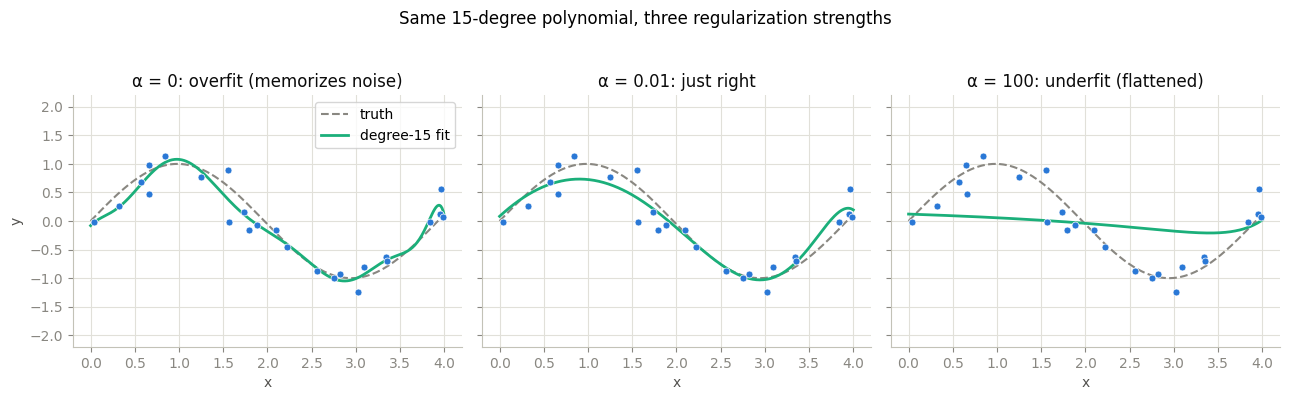

In [12]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

true_f = lambda x: np.sin(1.6 * x)
x_tr = np.sort(rng.uniform(0, 4, 25)); y_tr = true_f(x_tr) + rng.normal(0, 0.25, 25)
xs = np.linspace(0, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, alpha, label in zip(axes, [0.0, 0.01, 100.0],
                            ["α = 0: overfit (memorizes noise)", "α = 0.01: just right", "α = 100: underfit (flattened)"]):
    model = make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=max(alpha, 1e-10)))
    model.fit(x_tr.reshape(-1, 1), y_tr)
    ax.scatter(x_tr, y_tr, s=25, color=PALETTE[0], edgecolor="white", linewidth=0.5, zorder=3)
    ax.plot(xs, true_f(xs), color=GRAY, ls="--", lw=1.5, label="truth")
    ax.plot(xs, model.predict(xs.reshape(-1, 1)), color=PALETTE[1], lw=2, label="degree-15 fit")
    ax.set_ylim(-2.2, 2.2); ax.set_title(label); ax.set_xlabel("x")
axes[0].set_ylabel("y"); axes[0].legend(loc="upper right")
fig.suptitle("Same 15-degree polynomial, three regularization strengths", y=1.04)
plt.tight_layout(); plt.show()

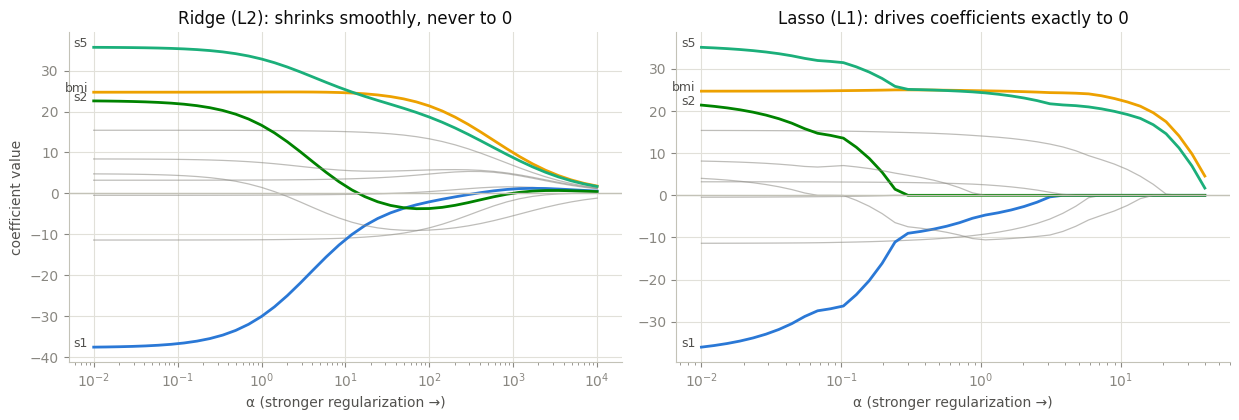

Lasso at α=1: nonzero coefficients: 7 of 10


In [13]:
# L2 vs L1 have different personalities. Watch every coefficient as alpha grows
# (diabetes dataset: 10 standardized clinical features -> disease progression).
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso

D = load_diabetes()
Xd = StandardScaler().fit_transform(D.data); yd = D.target

alphas_r = np.logspace(-2, 4, 40); alphas_l = np.logspace(-2, 1.6, 40)
coefs_r = np.array([Ridge(alpha=a).fit(Xd, yd).coef_ for a in alphas_r])
coefs_l = np.array([Lasso(alpha=a, max_iter=50_000).fit(Xd, yd).coef_ for a in alphas_l])

top = np.argsort(-np.abs(coefs_r[0]))[:4]          # highlight the 4 biggest, gray the rest
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, alphas, coefs, name in [(axes[0], alphas_r, coefs_r, "Ridge (L2): shrinks smoothly, never to 0"),
                                (axes[1], alphas_l, coefs_l, "Lasso (L1): drives coefficients exactly to 0")]:
    for j in range(coefs.shape[1]):
        if j in top:
            ci = PALETTE[list(top).index(j)]
            ax.plot(alphas, coefs[:, j], color=ci, lw=2)
            ax.annotate(D.feature_names[j], (alphas[0], coefs[0, j]),
                        xytext=(-4, 0), textcoords="offset points",
                        ha="right", fontsize=9, color="#52514e")
        else:
            ax.plot(alphas, coefs[:, j], color=GRAY, lw=0.9, alpha=0.55)
    ax.set_xscale("log"); ax.axhline(0, color="#c3c2b7", lw=1)
    ax.set_xlabel("α (stronger regularization →)"); ax.set_title(name)
axes[0].set_ylabel("coefficient value")
plt.tight_layout(); plt.show()

print("Lasso at α=1: nonzero coefficients:",
      int((Lasso(alpha=1, max_iter=50_000).fit(Xd, yd).coef_ != 0).sum()), "of 10")

**Ridge** shrinks all weights smoothly toward zero — good default, handles correlated features gracefully.
**Lasso** zeroes weights out entirely, performing **automatic feature selection** — the surviving features
are the ones the model considers essential. (Geometric reason: the L1 penalty's constraint region is a
diamond whose *corners* sit on the axes, and optima land on corners.) `ElasticNet` blends both.

**Non-negotiable:** regularization penalizes coefficient *size*, so features must be standardized first —
otherwise the penalty arbitrarily punishes features with small units. Note we always pick $\alpha$ by
cross-validation (section 11), never by eyeballing.

<a id="9"></a>
## 9. The bias–variance tradeoff

Why exactly does flexibility cut both ways? Decompose the expected squared error of a model class at
a point $x$, over many possible training sets:

$$\mathbb{E}\big[(y - \hat f(x))^2\big] =
\underbrace{\big(\mathbb{E}[\hat f(x)] - f(x)\big)^2}_{\textbf{bias}^2\;\text{(systematically wrong)}} +
\underbrace{\mathbb{E}\big[(\hat f(x) - \mathbb{E}[\hat f(x)])^2\big]}_{\textbf{variance}\;\text{(unstable across datasets)}} +
\underbrace{\sigma^2}_{\text{irreducible noise}}$$

This is not a metaphor — we can *measure* each term by simulation: draw many training sets from the
same world, fit the same model class to each, and watch how the fits scatter.

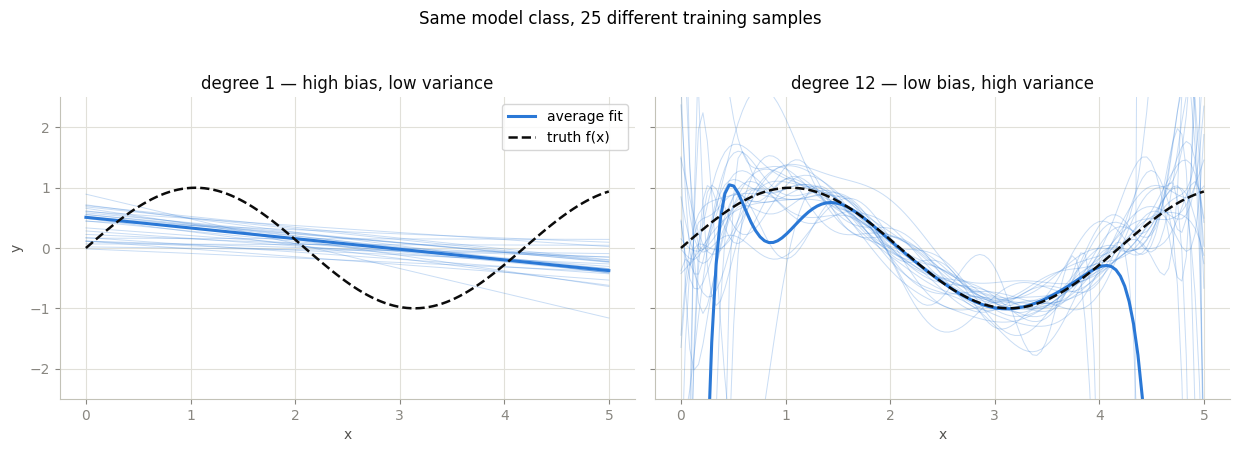

In [14]:
from numpy.polynomial import Polynomial

f_true = lambda x: np.sin(1.5 * x)
xg = np.linspace(0, 5, 120)                        # evaluation grid
NOISE, N_SETS, N_PTS = 0.4, 200, 30

def fits_for_degree(deg):
    preds = np.empty((N_SETS, len(xg)))
    for s in range(N_SETS):
        xi = rng.uniform(0, 5, N_PTS)
        yi = f_true(xi) + rng.normal(0, NOISE, N_PTS)
        preds[s] = Polynomial.fit(xi, yi, deg)(xg)
    return preds

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharey=True)
for ax, deg, name in [(axes[0], 1, "degree 1 — high bias, low variance"),
                      (axes[1], 12, "degree 12 — low bias, high variance")]:
    preds = fits_for_degree(deg)
    for s in range(25):
        ax.plot(xg, preds[s], color=PALETTE[0], lw=0.7, alpha=0.25)
    ax.plot(xg, preds.mean(0), color=PALETTE[0], lw=2.2, label="average fit")
    ax.plot(xg, f_true(xg), color="#0b0b0b", ls="--", lw=1.8, label="truth f(x)")
    ax.set_ylim(-2.5, 2.5); ax.set_title(name); ax.set_xlabel("x")
axes[0].set_ylabel("y"); axes[0].legend(loc="upper right")
fig.suptitle("Same model class, 25 different training samples", y=1.04)
plt.tight_layout(); plt.show()

Left: every straight line lands in nearly the same (wrong) place — **consistently wrong = bias**.
Right: each degree-12 fit chases its own sample's noise — **inconsistently right = variance**; yet their
*average* hugs the truth. Now sweep the degree and measure both terms:

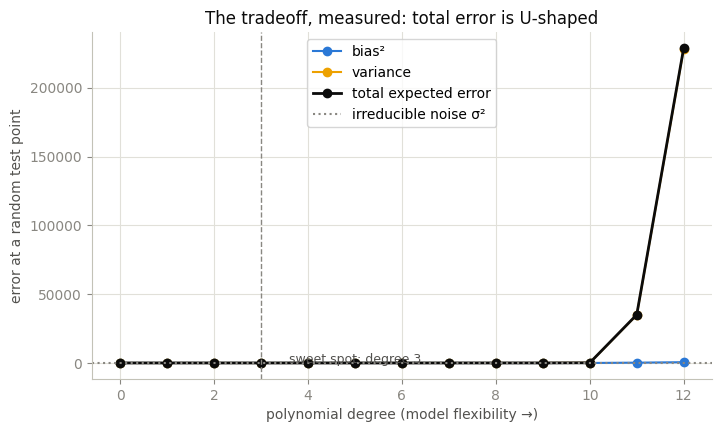

In [15]:
degrees = np.arange(0, 13)
bias2, var = [], []
for d in degrees:
    preds = fits_for_degree(d)
    bias2.append(((preds.mean(0) - f_true(xg)) ** 2).mean())
    var.append(preds.var(0).mean())
bias2, var = np.array(bias2), np.array(var)
total = bias2 + var + NOISE ** 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, bias2, "o-", color=PALETTE[0], label="bias²")
ax.plot(degrees, var, "o-", color=PALETTE[2], label="variance")
ax.plot(degrees, total, "o-", color="#0b0b0b", lw=2, label="total expected error")
ax.axhline(NOISE ** 2, color=GRAY, ls=":", lw=1.5, label="irreducible noise σ²")
best = degrees[np.argmin(total)]
ax.axvline(best, color=GRAY, lw=1, ls="--")
ax.annotate(f"sweet spot: degree {best}", (best, total.min()),
            xytext=(best + 0.6, total.min() + 0.15), color="#52514e", fontsize=9)
ax.set_xlabel("polynomial degree (model flexibility →)")
ax.set_ylabel("error at a random test point")
ax.set_title("The tradeoff, measured: total error is U-shaped")
ax.legend()
plt.show()

This U-curve is the master diagram of machine learning. Everything else in the notebook is a strategy
for navigating it:

| Symptom | Diagnosis | Remedies |
|---|---|---|
| train error high, test ≈ train | **high bias** (underfit) | more flexible model, better features, less regularization |
| train error ≈ 0, test much worse | **high variance** (overfit) | more data, regularization, simpler model, **averaging (ensembles!)** |

Note the fine print from the right panel above: high-variance models *average* to the truth. That single
observation is the seed of random forests (section 13).

<a id="10"></a>
## 10. Evaluating classifiers: metrics from scratch

Accuracy is one number, and often the wrong one. The full story of a binary classifier is the
**confusion matrix**:

| | predicted 0 | predicted 1 |
|---|---|---|
| **actual 0** | TN | FP (false alarm) |
| **actual 1** | FN (miss) | TP |

From it:
$$\text{precision} = \frac{TP}{TP+FP} \;\text{("when it cries wolf, is there a wolf?")}
\qquad
\text{recall} = \frac{TP}{TP+FN} \;\text{("of all wolves, how many caught?")}$$

$$F_1 = \text{harmonic mean(precision, recall)} \qquad\qquad
\text{accuracy} = \frac{TP+TN}{n}$$

In [16]:
Xc, yc = make_classification(n_samples=900, n_features=8, n_informative=5,
                             flip_y=0.06, class_sep=0.9, random_state=5)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.35, random_state=0, stratify=yc)
clf = LogisticRegression().fit(Xc_tr, yc_tr)
scores = clf.predict_proba(Xc_te)[:, 1]            # P(y=1), the raw material for every metric
y_hat = (scores >= 0.5).astype(int)

def confusion(y, yh):
    tp = ((y == 1) & (yh == 1)).sum(); tn = ((y == 0) & (yh == 0)).sum()
    fp = ((y == 0) & (yh == 1)).sum(); fn = ((y == 1) & (yh == 0)).sum()
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion(yc_te, y_hat)
prec, rec = tp / (tp + fp), tp / (tp + fn)
f1 = 2 * prec * rec / (prec + rec)
print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
print(f"accuracy={ (tp+tn)/len(yc_te):.3f}  precision={prec:.3f}  recall={rec:.3f}  F1={f1:.3f}")

from sklearn.metrics import classification_report
print("\nsklearn agrees:\n", classification_report(yc_te, y_hat, digits=3))

TP=126 TN=132 FP=23 FN=34
accuracy=0.819  precision=0.846  recall=0.787  F1=0.816

sklearn agrees:
               precision    recall  f1-score   support

           0      0.795     0.852     0.822       155
           1      0.846     0.787     0.816       160

    accuracy                          0.819       315
   macro avg      0.820     0.820     0.819       315
weighted avg      0.821     0.819     0.819       315



The 0.5 threshold above was a *choice*, not a law. Slide it and precision/recall trade against each
other; sliding it across **all** values traces the **ROC curve** (true-positive rate vs false-positive
rate). Its area (**AUC**) is threshold-free: the probability that a random positive example scores
higher than a random negative one. Both from scratch:

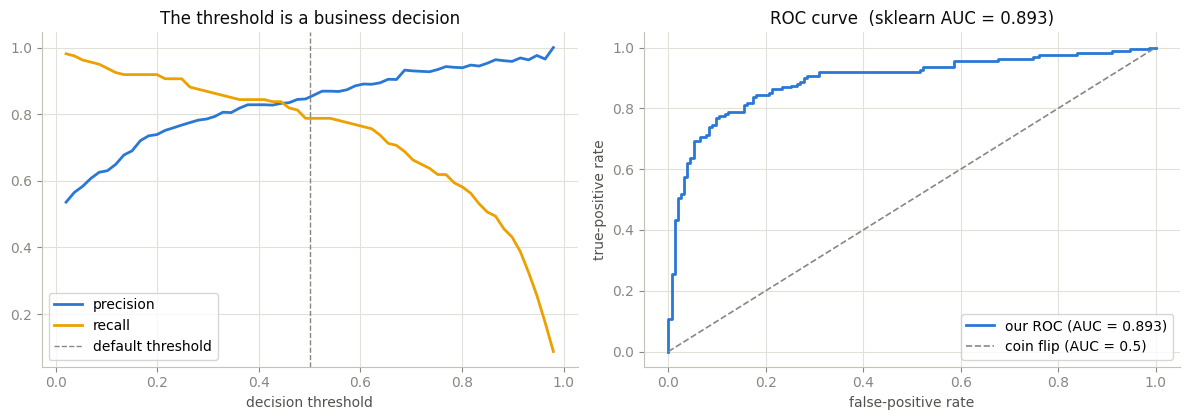

In [17]:
def roc_scratch(y, s):
    order = np.argsort(-s)                          # sweep threshold from high to low
    ys = y[order]
    tpr = np.cumsum(ys) / ys.sum()
    fpr = np.cumsum(1 - ys) / (1 - ys).sum()
    return np.r_[0, fpr], np.r_[0, tpr]

fpr, tpr = roc_scratch(yc_te, scores)
auc = np.trapezoid(tpr, fpr)

thresholds = np.linspace(0.02, 0.98, 60)
pr = [((yc_te[(scores >= t)] == 1).mean() if (scores >= t).any() else 1.0) for t in thresholds]
rc = [((scores[yc_te == 1] >= t).mean()) for t in thresholds]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.plot(thresholds, pr, color=PALETTE[0], lw=2, label="precision")
ax1.plot(thresholds, rc, color=PALETTE[2], lw=2, label="recall")
ax1.axvline(0.5, color=GRAY, ls="--", lw=1, label="default threshold")
ax1.set_xlabel("decision threshold"); ax1.set_title("The threshold is a business decision")
ax1.legend()

ax2.plot(fpr, tpr, color=PALETTE[0], lw=2, label=f"our ROC (AUC = {auc:.3f})")
ax2.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1.2, label="coin flip (AUC = 0.5)")
from sklearn.metrics import roc_auc_score
ax2.set_xlabel("false-positive rate"); ax2.set_ylabel("true-positive rate")
ax2.set_title(f"ROC curve  (sklearn AUC = {roc_auc_score(yc_te, scores):.3f})")
ax2.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Choosing the threshold is product design, not math**: a cancer screener wants high recall (misses are
catastrophic, false alarms get re-tested); a spam filter wants high precision (deleting real mail is
worse than seeing spam). Section 22 chooses a threshold from actual dollar costs.

For **regression**, the standard trio: MAE (average miss, in original units), RMSE (like MAE but
punishes big misses), and $R^2 = 1 - \frac{\sum(y-\hat y)^2}{\sum(y-\bar y)^2}$ (fraction of variance
explained; 0 = no better than predicting the mean; can go negative).

<a id="11"></a>
## 11. Cross-validation and data leakage

One train/test split gives one noisy estimate — and if you *tune* on the test set, you quietly overfit
to it. **k-fold cross-validation** fixes both: split the training data into $k$ folds, train on $k{-}1$,
validate on the held-out one, rotate, and average. Every point gets used for both training and
validation, and you get a mean **± spread**.

In [18]:
def kfold_cv(model_factory, X, y, k=5):
    idx = np.arange(len(X)); rng.shuffle(idx)
    folds = np.array_split(idx, k)
    scores = []
    for i in range(k):
        val = folds[i]
        trn = np.concatenate([folds[j] for j in range(k) if j != i])
        m = model_factory().fit(X[trn], y[trn])
        scores.append(m.score(X[val], y[val]))
    return np.array(scores)

ours = kfold_cv(lambda: LogisticRegression(), Xc, yc, k=5)
print(f"our 5-fold CV:      {ours.mean():.3f} ± {ours.std():.3f}   folds: {np.round(ours, 3)}")

from sklearn.model_selection import cross_val_score
sk_scores = cross_val_score(LogisticRegression(), Xc, yc, cv=5)
print(f"sklearn 5-fold CV:  {sk_scores.mean():.3f} ± {sk_scores.std():.3f}")

our 5-fold CV:      0.853 ± 0.009   folds: [0.867 0.839 0.85  0.856 0.856]
sklearn 5-fold CV:  0.848 ± 0.019


### Data leakage: the silent killer

**Leakage** = information from the validation/test data sneaking into training. It produces beautiful
scores that evaporate in production. The nastiest version: doing *any* data-dependent preprocessing
(scaling, feature selection, imputation) on the **full** dataset before splitting.

Watch it manufacture skill out of pure noise — 100 samples, 2,000 **random** features, random labels.
True accuracy is 50% by construction:

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

Xr = rng.normal(size=(100, 2000))
yr = rng.integers(0, 2, 100)                        # labels are pure coin flips

# WRONG: select the 20 "best" features using ALL rows, then cross-validate
X_sel = SelectKBest(f_classif, k=20).fit_transform(Xr, yr)
wrong = cross_val_score(LogisticRegression(), X_sel, yr, cv=5).mean()

# RIGHT: selection lives INSIDE the pipeline, so it's re-fit on each fold's training part only
pipe = Pipeline([("select", SelectKBest(f_classif, k=20)),
                 ("clf", LogisticRegression())])
right = cross_val_score(pipe, Xr, yr, cv=5).mean()

print(f"leaky protocol:   {wrong:.3f}  <- fantasy skill on coin-flip labels!")
print(f"proper pipeline:  {right:.3f}  <- the honest ~0.5")

leaky protocol:   0.790  <- fantasy skill on coin-flip labels!
proper pipeline:  0.480  <- the honest ~0.5


The leaky protocol scores far above chance *on random labels* — the feature selector peeked at the
validation rows when choosing features. The fix is mechanical: **every data-dependent step goes inside
a `Pipeline`**, so cross-validation re-fits the whole chain on each fold's training portion.

Other leakage flavors to watch for: target leakage (a feature that is a *consequence* of the label,
e.g. "account_closed" when predicting churn), temporal leakage (training on the future — use time-based
splits for time series), and duplicate rows straddling the split.

<a id="12"></a>
## 12. Decision trees from scratch

A decision tree classifies with nested if/else questions: *"is $x_1 < 2.3$? then is $x_0 < -1$? …"*.
Training grows the tree greedily: at each node, try every feature and threshold, and keep the split
that makes the two children **purest**. Purity is measured by **Gini impurity** — the chance two random
draws from a node disagree:

$$G = 1 - \sum_c p_c^2 \qquad (0 = \text{pure}, \; 0.5 = \text{50/50 coin flip})$$

A split's quality is the sample-weighted impurity of its children; lower is better.

In [20]:
def gini_from_counts(pos, tot):
    p = pos / tot
    return 2 * p * (1 - p)                          # binary Gini

def best_split(X, y):
    """Try every (feature, threshold); return the one minimizing weighted child impurity.
    Vectorized: sort once per feature, then cumulative sums score all thresholds at once."""
    n = len(y)
    best = (None, None, np.inf)
    for j in range(X.shape[1]):
        order = np.argsort(X[:, j])
        xs, ys = X[order, j], y[order]
        left_pos = np.cumsum(ys)[:-1]               # positives left of each cut
        left_n = np.arange(1, n)
        right_pos = ys.sum() - left_pos
        right_n = n - left_n
        w_gini = (left_n * gini_from_counts(left_pos, left_n)
                  + right_n * gini_from_counts(right_pos, right_n)) / n
        w_gini[xs[1:] == xs[:-1]] = np.inf          # can't cut between equal values
        i = int(np.argmin(w_gini))
        if w_gini[i] < best[2]:
            best = (j, (xs[i] + xs[i + 1]) / 2, w_gini[i])
    return best

def grow_tree(X, y, depth=0, max_depth=4, min_leaf=3):
    node = {"n": len(y), "pred": int(np.round(y.mean()))}
    if depth == max_depth or len(np.unique(y)) == 1 or len(y) < 2 * min_leaf:
        return node
    j, t, score = best_split(X, y)
    if j is None or score >= gini_from_counts(y.sum(), len(y)):
        return node                                 # no split improves purity
    L = X[:, j] <= t
    if L.sum() < min_leaf or (~L).sum() < min_leaf:
        return node
    node.update(feature=j, threshold=t,
                left=grow_tree(X[L], y[L], depth + 1, max_depth, min_leaf),
                right=grow_tree(X[~L], y[~L], depth + 1, max_depth, min_leaf))
    return node

def tree_predict_one(node, x):
    while "feature" in node:
        node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
    return node["pred"]

def tree_predict(node, X):
    return np.array([tree_predict_one(node, x) for x in X])

tree4 = grow_tree(Xm_tr, ym_tr, max_depth=4)
acc4 = (tree_predict(tree4, Xm_te) == ym_te).mean()

from sklearn.tree import DecisionTreeClassifier
sk_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=0).fit(Xm_tr, ym_tr)
print(f"our tree (depth 4) test acc:     {acc4:.3f}")
print(f"sklearn tree (depth 4) test acc: {sk_tree.score(Xm_te, ym_te):.3f}")

our tree (depth 4) test acc:     0.858
sklearn tree (depth 4) test acc: 0.858


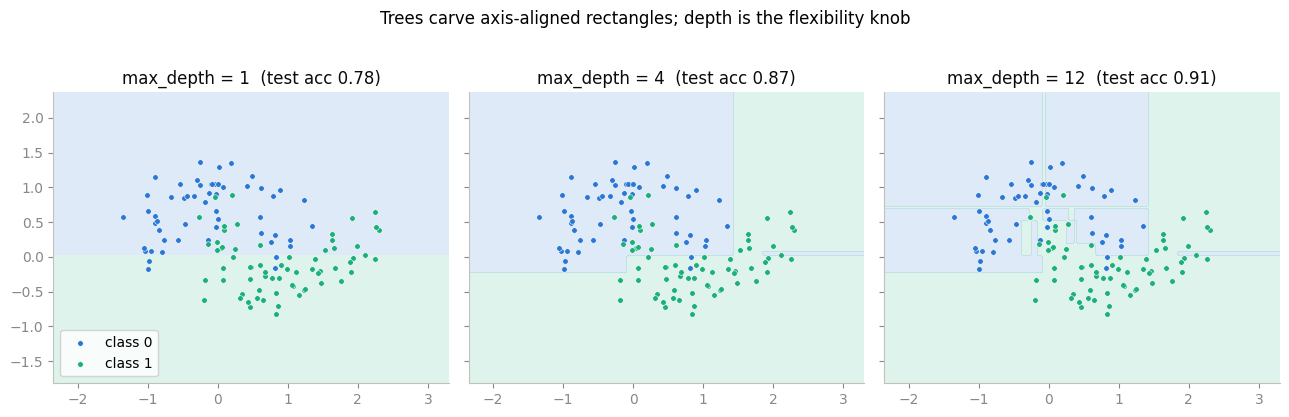

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, d in zip(axes, [1, 4, 12]):
    t = grow_tree(Xm_tr, ym_tr, max_depth=d, min_leaf=1)
    acc = (tree_predict(t, Xm_te) == ym_te).mean()
    plot_regions(lambda G, t=t: tree_predict(t, G), Xm_te, ym_te, ax,
                 title=f"max_depth = {d}  (test acc {acc:.2f})", res=150)
axes[0].legend(loc="lower left")
fig.suptitle("Trees carve axis-aligned rectangles; depth is the flexibility knob", y=1.03)
plt.tight_layout(); plt.show()

Recognize the moons dataset that defeated logistic regression? The tree handles the curve effortlessly —
by stacking rectangles. Depth 1 (a "stump") underfits; depth 12 shatters into noise-chasing islands —
the k-NN story again, because it's *always* the same story.

**Why trees are beloved:** no feature scaling needed, native handling of mixed/categorical-ish data,
fully interpretable (you can print the rules), and they capture feature *interactions* automatically.
**Why single trees are rarely deployed:** they are *high-variance* — nudge the data and the whole
structure reshuffles. But section 9 told us what to do with high-variance models: average them.

<a id="13"></a>
## 13. Bagging and random forests

If you average $B$ estimates that each have variance $\sigma^2$ and pairwise correlation $\rho$:

$$\operatorname{Var}(\text{average}) = \rho\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

More trees ($B\uparrow$) kills the second term; making trees *less correlated* ($\rho\downarrow$) kills the
first. Random forests attack both:
1. **Bagging** (bootstrap aggregating): train each tree on a random sample-with-replacement of the data.
2. **Feature subsampling**: each split may only consider a random subset of features (decorrelates trees).
3. Predict by majority vote (or averaged probabilities).

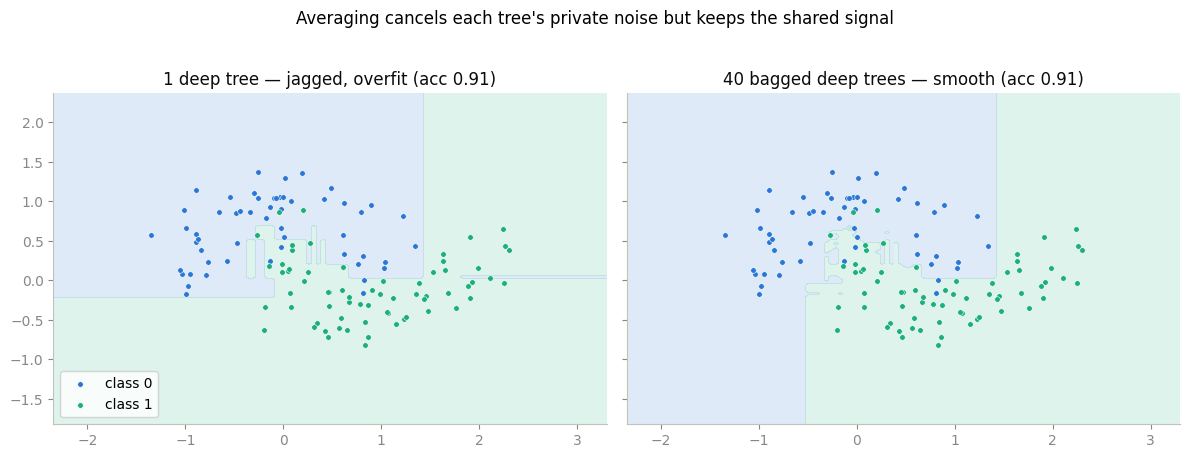

In [22]:
def bagged_trees(X, y, n_trees=40, max_depth=12):
    trees = []
    for _ in range(n_trees):
        idx = rng.integers(0, len(X), len(X))       # bootstrap sample (with replacement)
        trees.append(grow_tree(X[idx], y[idx], max_depth=max_depth, min_leaf=1))
    return trees

def bag_predict(trees, X):
    votes = np.stack([tree_predict(t, X) for t in trees])
    return (votes.mean(0) >= 0.5).astype(int)

deep_tree = grow_tree(Xm_tr, ym_tr, max_depth=12, min_leaf=1)
forest = bagged_trees(Xm_tr, ym_tr, n_trees=40)

acc_one = (tree_predict(deep_tree, Xm_te) == ym_te).mean()
acc_bag = (bag_predict(forest, Xm_te) == ym_te).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
plot_regions(lambda G: tree_predict(deep_tree, G), Xm_te, ym_te, axes[0],
             title=f"1 deep tree — jagged, overfit (acc {acc_one:.2f})", res=120)
plot_regions(lambda G: bag_predict(forest, G), Xm_te, ym_te, axes[1],
             title=f"40 bagged deep trees — smooth (acc {acc_bag:.2f})", res=120)
axes[0].legend(loc="lower left")
fig.suptitle("Averaging cancels each tree's private noise but keeps the shared signal", y=1.03)
plt.tight_layout(); plt.show()

OOB estimate (free validation from bootstrap leftovers): 0.940
actual test accuracy:                                    0.922


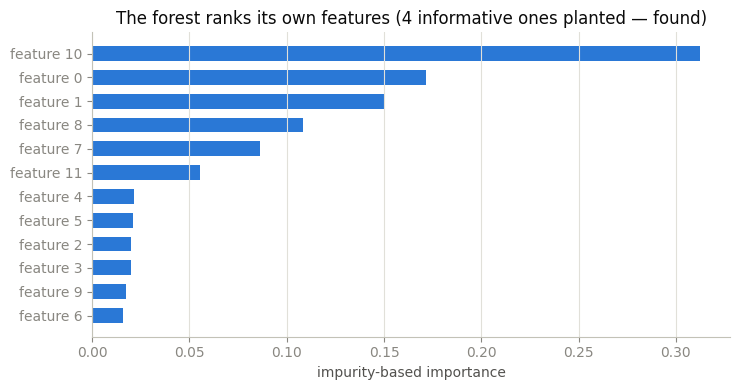

In [23]:
# The production version, with two freebies: OOB score and feature importances.
from sklearn.ensemble import RandomForestClassifier

Xf, yf = make_classification(n_samples=1200, n_features=12, n_informative=4, n_redundant=2,
                             flip_y=0.05, random_state=8)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, random_state=0)

rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=0, n_jobs=-1)
rf.fit(Xf_tr, yf_tr)
print(f"OOB estimate (free validation from bootstrap leftovers): {rf.oob_score_:.3f}")
print(f"actual test accuracy:                                    {rf.score(Xf_te, yf_te):.3f}")

imp = rf.feature_importances_
order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh([f"feature {i}" for i in order], imp[order], color=PALETTE[0], height=0.62)
ax.set_xlabel("impurity-based importance")
ax.set_title("The forest ranks its own features (4 informative ones planted — found)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Each bootstrap sample leaves out ~37% of rows; scoring every tree on its own left-out rows gives the
**out-of-bag (OOB) estimate** — honest validation with no held-out set.

Random forests are the great **default model for tabular data**: nearly tuning-free, hard to overfit
by adding trees (more trees only reduces variance), robust to feature scales and outliers. Caveats:
impurity importances are biased toward high-cardinality features (prefer *permutation importance*,
section 23), and forests can't extrapolate beyond the range of the training targets.

<a id="14"></a>
## 14. Gradient boosting

Bagging builds strong learners **in parallel** and averages away variance. Boosting is the opposite
personality: build weak learners **in sequence**, each one correcting what the ensemble so far got wrong.

For squared error the recipe is beautifully simple, because the negative gradient of the loss *is* the
residual $y - F(x)$:

1. Start with the best constant: $F_0(x) = \bar y$.
2. Repeat: fit a small tree $h_m$ to the **residuals** $y - F_{m-1}(x)$, then update
   $F_m = F_{m-1} + \eta\, h_m$ with learning rate $\eta$.

Each round nudges predictions toward whatever error remains. Watch it assemble a sine wave out of stumps:

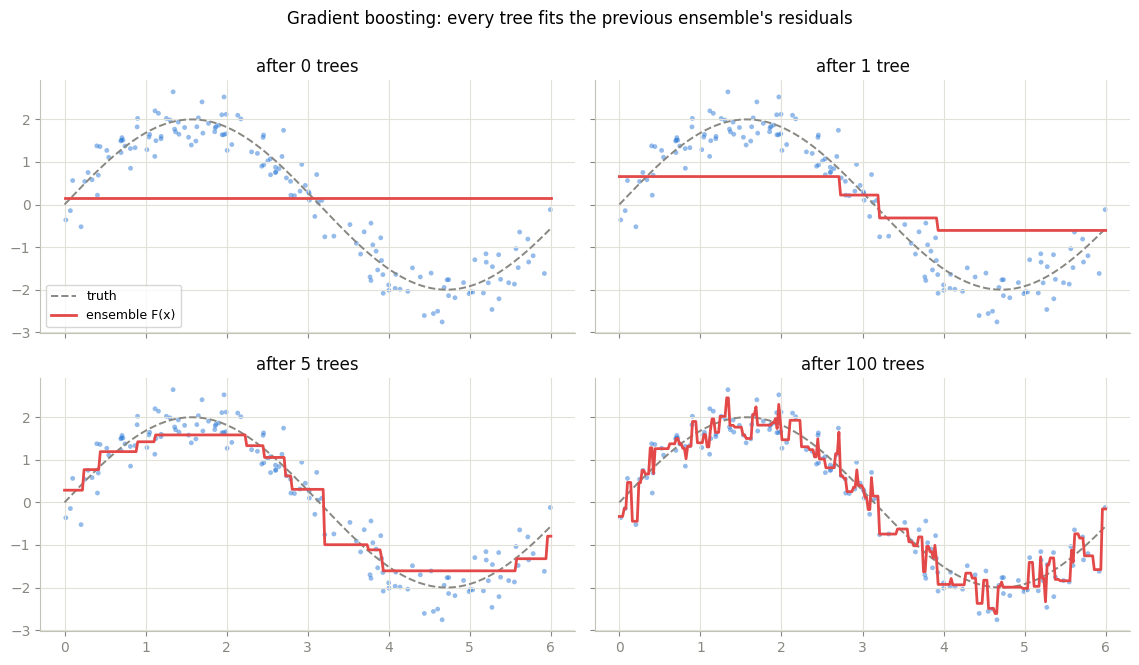

In [24]:
from sklearn.tree import DecisionTreeRegressor

xb = np.sort(rng.uniform(0, 6, 150))
yb2 = np.sin(xb) * 2 + rng.normal(0, 0.35, 150)
xs6 = np.linspace(0, 6, 300)

eta = 0.4
F = np.full_like(yb2, yb2.mean())                   # running prediction on train points
F_grid = np.full_like(xs6, yb2.mean())              # same, on the plotting grid
snapshots = {0: F_grid.copy()}
for mstep in range(1, 101):
    resid = yb2 - F
    stump = DecisionTreeRegressor(max_depth=2, random_state=0).fit(xb.reshape(-1, 1), resid)
    F += eta * stump.predict(xb.reshape(-1, 1))
    F_grid += eta * stump.predict(xs6.reshape(-1, 1))
    if mstep in (1, 5, 100):
        snapshots[mstep] = F_grid.copy()

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.6), sharex=True, sharey=True)
for ax, (mstep, Fg) in zip(axes.ravel(), snapshots.items()):
    ax.scatter(xb, yb2, s=12, color=PALETTE[0], alpha=0.5, edgecolor="none")
    ax.plot(xs6, np.sin(xs6) * 2, color=GRAY, ls="--", lw=1.4, label="truth")
    ax.plot(xs6, Fg, color=PALETTE[5], lw=2, label="ensemble F(x)")
    ax.set_title(f"after {mstep} tree{'s' if mstep != 1 else ''}")
axes[0, 0].legend(loc="lower left", fontsize=9)
fig.suptitle("Gradient boosting: every tree fits the previous ensemble's residuals", y=1.0)
plt.tight_layout(); plt.show()

For other losses (log loss, MAE, …) the same recipe fits each tree to the loss's **negative gradient** —
hence *gradient* boosting: it is gradient descent **in function space**, one tree per step.

Because boosting attacks *bias* round after round, it can also march straight into overfitting —
unlike a forest, **more boosting rounds eventually hurt**. The learning rate trades rounds for
generalization (smaller $\eta$ + more trees ≈ better, slower). Watch both effects live:

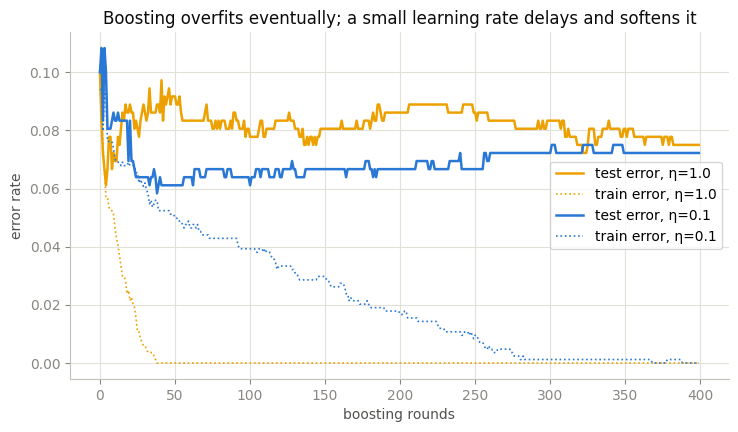

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xf, yf, test_size=0.3, random_state=1)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for eta_i, color in zip([1.0, 0.1], [PALETTE[2], PALETTE[0]]):
    gb = GradientBoostingClassifier(n_estimators=400, learning_rate=eta_i,
                                    max_depth=2, random_state=0).fit(Xg_tr, yg_tr)
    test_err = [1 - (p == yg_te).mean() for p in gb.staged_predict(Xg_te)]
    trn_err = [1 - (p == yg_tr).mean() for p in gb.staged_predict(Xg_tr)]
    ax.plot(test_err, color=color, lw=1.8, label=f"test error, η={eta_i}")
    ax.plot(trn_err, color=color, lw=1.2, ls=":", label=f"train error, η={eta_i}")
ax.set_xlabel("boosting rounds"); ax.set_ylabel("error rate")
ax.set_title("Boosting overfits eventually; a small learning rate delays and softens it")
ax.legend()
plt.show()

**State of the art for tabular data.** Modern implementations — `HistGradientBoostingClassifier`
(sklearn), XGBoost, LightGBM, CatBoost — add histogram binning (speed), second-order gradients,
clever regularization, and early stopping on a validation set. On most tabular benchmarks they beat
neural networks. Key knobs, in tuning order: `learning_rate` + number of trees (tune jointly, use early
stopping), `max_depth`/`max_leaf_nodes` (keep small: 2–8 levels), then subsampling rates.

<a id="15"></a>
## 15. Support vector machines and the kernel trick

Many separating lines may achieve zero training error — which is *best*? The SVM answers: the one with
the **maximum margin**, the widest street between the classes. Only the points touching the street
(the **support vectors**) define it; every other point could move without changing the answer.

$$\min_{w,b} \;\tfrac12 \lVert w\rVert^2 + C\sum_i \max\!\big(0,\, 1 - y_i(w^\top x_i + b)\big)$$

That second term is the hinge loss from section 4; $C$ sets how expensive margin violations are
(**large $C$ → strict → wiggly/overfit; small $C$ → tolerant → smooth**).

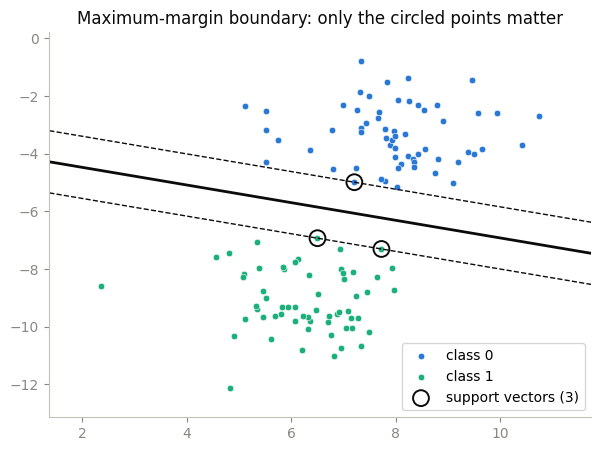

In [26]:
from sklearn.svm import SVC

Xs2, ys2 = make_blobs(n_samples=120, centers=2, cluster_std=1.1, random_state=6)
svm_lin = SVC(kernel="linear", C=1.0).fit(Xs2, ys2)

fig, ax = plt.subplots(figsize=(7, 5))
for c in (0, 1):
    m = ys2 == c
    ax.scatter(Xs2[m, 0], Xs2[m, 1], s=22, color=PALETTE[c],
               edgecolor="white", linewidth=0.4, label=f"class {c}")
gx = np.linspace(Xs2[:, 0].min() - 1, Xs2[:, 0].max() + 1, 200)
gy = np.linspace(Xs2[:, 1].min() - 1, Xs2[:, 1].max() + 1, 200)
GX, GY = np.meshgrid(gx, gy)
Z = svm_lin.decision_function(np.c_[GX.ravel(), GY.ravel()]).reshape(GX.shape)
ax.contour(GX, GY, Z, levels=[-1, 0, 1], colors=["#0b0b0b"], linewidths=[1, 2, 1],
           linestyles=["--", "-", "--"])
sv = svm_lin.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="#0b0b0b",
           linewidths=1.4, label=f"support vectors ({len(sv)})")
ax.legend(loc="lower right"); ax.grid(False)
ax.set_title("Maximum-margin boundary: only the circled points matter")
plt.show()

### The kernel trick

To get nonlinear boundaries we *could* hand-engineer features like in section 8. The kernel trick does
it implicitly: the SVM's math only ever needs **dot products** $x_i^\top x_j$, so replace them with a
kernel $K(x_i, x_j) = \phi(x_i)^\top \phi(x_j)$ — a similarity function that equals a dot product in some
(possibly infinite-dimensional!) feature space you never have to construct. The workhorse is the
**RBF (Gaussian) kernel**:

$$K(a, b) = \exp\!\big(-\gamma \lVert a-b\rVert^2\big)$$

$\gamma$ sets how far a training point's influence reaches — it's the flexibility knob:

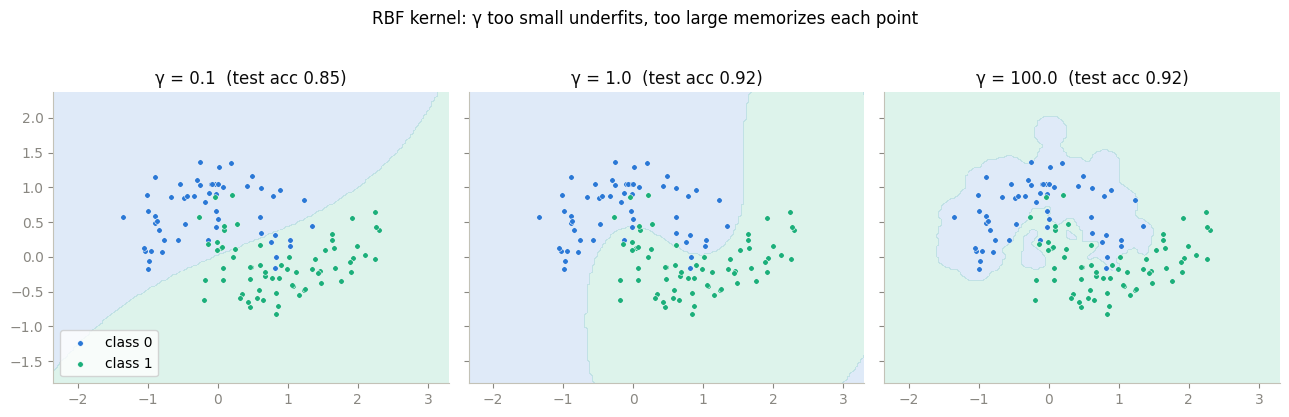

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, gamma in zip(axes, [0.1, 1.0, 100.0]):
    svm = SVC(kernel="rbf", gamma=gamma, C=1.0).fit(Xm_tr, ym_tr)
    acc = svm.score(Xm_te, ym_te)
    plot_regions(svm.predict, Xm_te, ym_te, ax,
                 title=f"γ = {gamma}  (test acc {acc:.2f})", res=150)
axes[0].legend(loc="lower left")
fig.suptitle("RBF kernel: γ too small underfits, too large memorizes each point", y=1.03)
plt.tight_layout(); plt.show()

The same tradeoff for the third time — γ here, depth for trees, k for k-NN. **Expert instinct:** when you
meet a new model, your first question is "which knob controls flexibility, and which direction is which?"

SVM practicalities: **standardize features** (kernels are distance-based), tune $C$ and $\gamma$ jointly
on a log grid (section 20 does exactly this), and note that training is roughly $O(n^2)$ — brilliant up to
~50k samples, painful beyond. `probability=True` bolts on calibrated probabilities via internal CV.

<a id="16"></a>
## 16. Neural networks from scratch: backpropagation

A neural network is logistic regression stacked and composed. One **hidden layer** of $h$ units:

$$z^{(1)} = X W_1 + b_1 \qquad a = \tanh(z^{(1)}) \qquad z^{(2)} = a W_2 + b_2 \qquad p = \sigma(z^{(2)})$$

The nonlinearity ($\tanh$) is the entire point — without it the two layers would collapse into one linear
map. With it, enough hidden units can approximate *any* continuous function (the universal approximation
theorem). The hidden layer **learns its own features**; that is the difference from section 8, where we
engineered them by hand.

**Backpropagation** is just the chain rule, applied layer by layer from the loss backwards.
For binary cross-entropy the output error starts as $\delta_2 = p - y$ (the same clean form as logistic
regression!), then flows backwards:

$$\frac{\partial J}{\partial W_2} = a^\top \delta_2, \qquad
\delta_1 = \delta_2 W_2^\top \odot (1 - a^2), \qquad
\frac{\partial J}{\partial W_1} = X^\top \delta_1$$

($1-a^2$ is $\tanh$'s derivative; $\odot$ is elementwise.) That's it. Every deep-learning framework is
this pattern, automated and scaled.

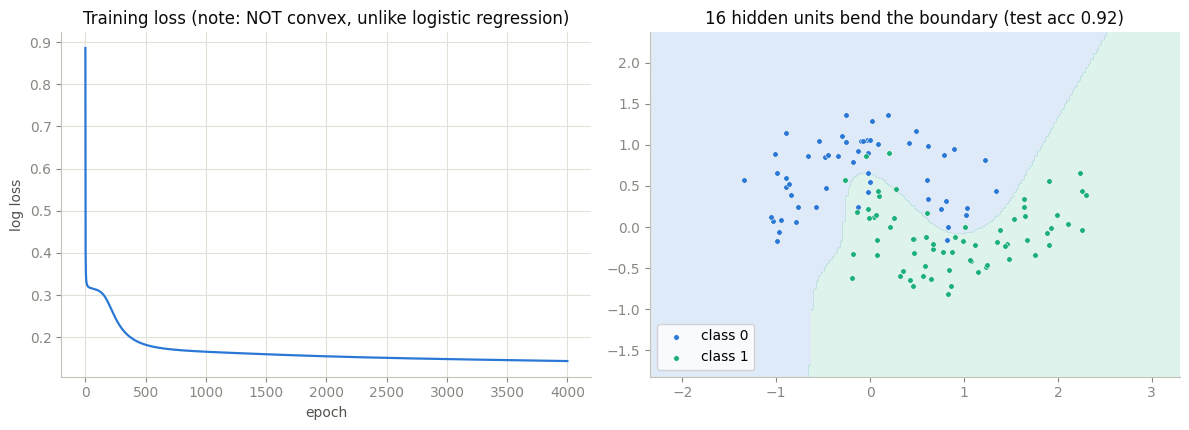

In [28]:
class TinyNet:
    """2-layer MLP: tanh hidden layer, sigmoid output, full-batch gradient descent."""
    def __init__(self, n_in, n_hidden, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, 1 / np.sqrt(n_in), (n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = r.normal(0, 1 / np.sqrt(n_hidden), (n_hidden, 1))
        self.b2 = np.zeros(1)

    def forward(self, X):
        self.a = np.tanh(X @ self.W1 + self.b1)     # hidden activations (cached for backprop)
        return sigmoid(self.a @ self.W2 + self.b2).ravel()

    def train(self, X, y, eta=0.8, epochs=4000):
        Y = y.reshape(-1, 1); losses = []
        for _ in range(epochs):
            p = self.forward(X).reshape(-1, 1)
            losses.append(-(Y * np.log(p + 1e-12) + (1 - Y) * np.log(1 - p + 1e-12)).mean())
            d2 = (p - Y) / len(y)                   # dJ/dz2
            dW2 = self.a.T @ d2                     # chain rule, layer 2
            db2 = d2.sum(0)
            d1 = (d2 @ self.W2.T) * (1 - self.a ** 2)   # flow back through tanh
            dW1 = X.T @ d1
            db1 = d1.sum(0)
            self.W1 -= eta * dW1; self.b1 -= eta * db1
            self.W2 -= eta * dW2; self.b2 -= eta * db2
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

net = TinyNet(2, 16, seed=1)
losses = net.train(Xm_tr, ym_tr)
acc = (net.predict(Xm_te) == ym_te).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.plot(losses, color=PALETTE[0], lw=1.6)
ax1.set_xlabel("epoch"); ax1.set_ylabel("log loss")
ax1.set_title("Training loss (note: NOT convex, unlike logistic regression)")
plot_regions(net.predict, Xm_te, ym_te, ax2,
             title=f"16 hidden units bend the boundary (test acc {acc:.2f})")
ax2.legend(loc="lower left")
plt.tight_layout(); plt.show()

Compare with section 7: the *same* moons data that capped a linear model at ~85% is now handled by
letting the model learn its own curved features. The loss surface is no longer convex — different
random initializations can land in different valleys (in practice, with enough width, almost all are
good valleys).

From here to deep learning is engineering, not new theory: more layers, ReLU instead of tanh, mini-batch
SGD with momentum/Adam, dropout & batch-norm, and autodiff so nobody writes backprop by hand. That path
continues in `pytorch_basics_to_expert.ipynb`. **When to reach for neural nets:** unstructured data
(images, text, audio) — for tabular data, gradient boosting (section 14) usually wins with far less effort.

<a id="17"></a>
## 17. Clustering: k-means from scratch

Unsupervised learning: no labels, find structure. **k-means** partitions data into $k$ clusters by
minimizing within-cluster squared distance (**inertia**), via a two-step dance that always converges:

1. **Assign** each point to its nearest centroid.
2. **Update** each centroid to the mean of its assigned points.
3. Repeat until nothing moves.

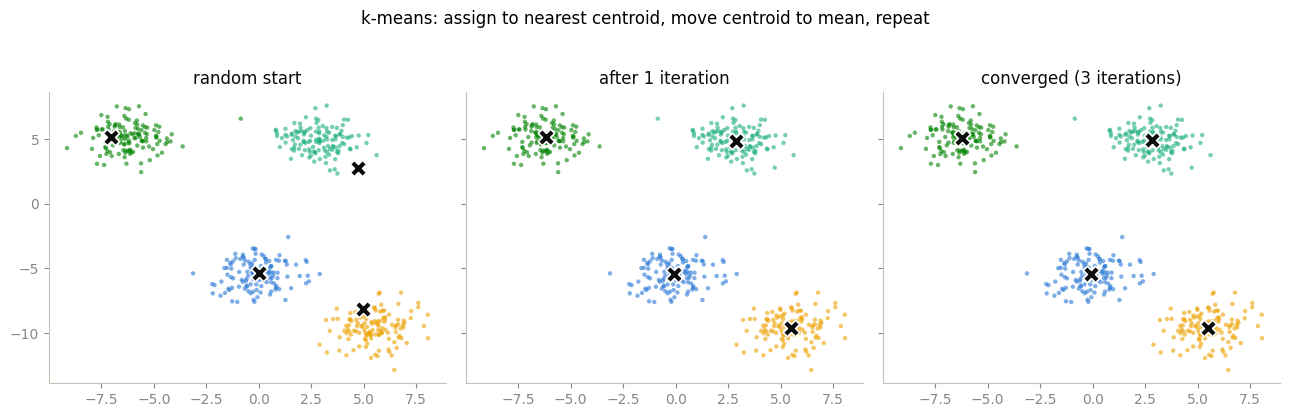

our inertia: 1054.9 | sklearn inertia: 1054.9


In [29]:
def kmeans(X, k, seed=0, iters=100):
    r = np.random.default_rng(seed)
    centers = X[r.choice(len(X), k, replace=False)].copy()
    history = [centers.copy()]
    for _ in range(iters):
        d = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = d.argmin(1)                        # assign
        new = np.array([X[labels == j].mean(0) if (labels == j).any() else centers[j]
                        for j in range(k)])         # update
        history.append(new.copy())
        if np.allclose(new, centers):
            break
        centers = new
    inertia = ((X - centers[labels]) ** 2).sum()
    return labels, centers, inertia, history

Xk, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.1, random_state=10)
labels, centers, inertia, hist = kmeans(Xk, 4, seed=3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, step in zip(axes, [0, 1, len(hist) - 1]):
    c_step = hist[step]
    lab = np.linalg.norm(Xk[:, None, :] - c_step[None, :, :], axis=2).argmin(1)
    for j in range(4):
        ax.scatter(Xk[lab == j, 0], Xk[lab == j, 1], s=10, color=PALETTE[j], alpha=0.6, edgecolor="none")
    ax.scatter(c_step[:, 0], c_step[:, 1], marker="X", s=140, color="#0b0b0b",
               edgecolor="white", linewidth=1.2, zorder=3)
    ax.set_title(["random start", "after 1 iteration", f"converged ({len(hist)-1} iterations)"][[0,1,len(hist)-1].index(step)])
    ax.grid(False)
fig.suptitle("k-means: assign to nearest centroid, move centroid to mean, repeat", y=1.03)
plt.tight_layout(); plt.show()

from sklearn.cluster import KMeans
print(f"our inertia: {inertia:.1f} | sklearn inertia: {KMeans(4, n_init=10, random_state=0).fit(Xk).inertia_:.1f}")

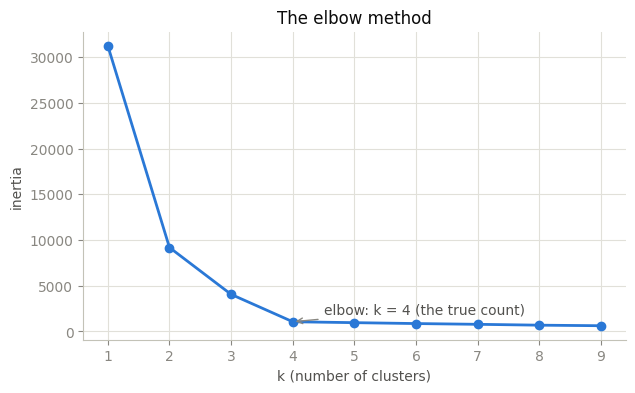

In [30]:
# How many clusters? Inertia always falls as k grows -- look for the "elbow"
# where adding a cluster stops paying for itself.
ks = range(1, 10)
inertias = [KMeans(k, n_init=10, random_state=0).fit(Xk).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), inertias, "o-", color=PALETTE[0], lw=2)
ax.annotate("elbow: k = 4 (the true count)", (4, inertias[3]),
            xytext=(4.5, inertias[3] + 900), color="#52514e", fontsize=10,
            arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_xlabel("k (number of clusters)"); ax.set_ylabel("inertia")
ax.set_title("The elbow method")
plt.show()

**Honest limitations:** k-means assumes clusters are round, similarly sized, and that you know $k$.
It hard-assigns every point (no "not sure", no outliers), converges only to a *local* optimum (hence
`n_init=10` restarts and k-means++ seeding), and — being distance-based — **needs scaled features**.
When clusters are elongated, nested, or vary in density, reach for Gaussian mixtures (soft, elliptical),
DBSCAN (density-based, finds outliers, no $k$ needed), or hierarchical clustering (gives a dendrogram).
The silhouette score is a more principled companion to the elbow plot.

<a id="18"></a>
## 18. Dimensionality reduction: PCA from scratch

**Principal Component Analysis** finds the orthogonal directions of maximum variance and re-expresses
the data in them, most-important first. Uses: compression, visualization of high-D data, noise
reduction, decorrelation before other models.

Recipe (this *is* the implementation): center the data, take the SVD $X_c = U S V^\top$; the rows of
$V^\top$ are the principal directions, projections are $X_c V$, and component $i$ explains
$S_i^2 / \sum_j S_j^2$ of the variance.

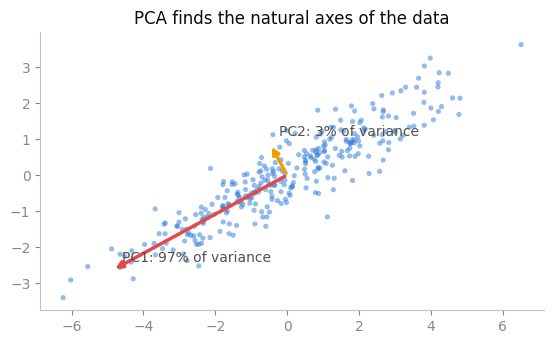

In [31]:
# 2-D intuition first: correlated data and its two principal axes.
A = rng.normal(size=(300, 2)) @ np.array([[2.2, 0.9], [0.9, 0.9]])   # correlated cloud
Ac = A - A.mean(0)
U, S, Vt = np.linalg.svd(Ac, full_matrices=False)
evr = S ** 2 / (S ** 2).sum()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(Ac[:, 0], Ac[:, 1], s=14, color=PALETTE[0], alpha=0.5, edgecolor="none")
for i, color in enumerate([PALETTE[5], PALETTE[2]]):
    v = Vt[i] * S[i] / np.sqrt(len(A))              # scale arrows by std along each axis
    ax.annotate("", xy=v * 2.2, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5))
    ax.annotate(f"PC{i+1}: {evr[i]:.0%} of variance", xy=v * 2.2, xytext=v * 2.2 + 0.25,
                color="#52514e", fontsize=10)
ax.set_aspect("equal"); ax.grid(False)
ax.set_title("PCA finds the natural axes of the data")
plt.show()

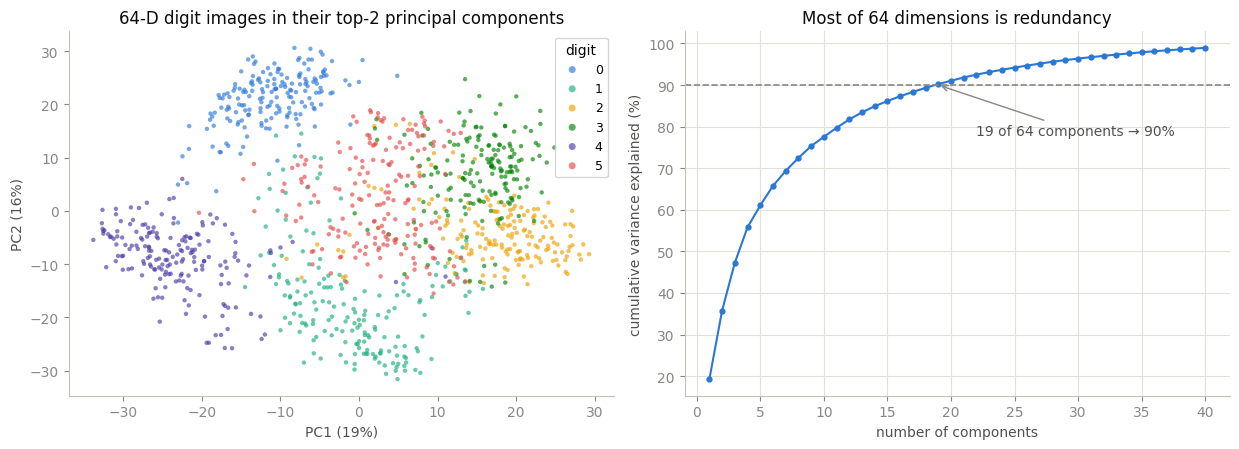

In [32]:
# Now the real deal: 8x8 handwritten digits = 64 dimensions, squeezed to 2 for viewing.
from sklearn.datasets import load_digits

digits = load_digits()
keep = digits.target < 6                            # 6 classes keeps the plot readable
Xd64, yd64 = digits.data[keep], digits.target[keep]

Xc64 = Xd64 - Xd64.mean(0)
U, S, Vt = np.linalg.svd(Xc64, full_matrices=False)
proj = Xc64 @ Vt[:2].T
evr64 = S ** 2 / (S ** 2).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for c in range(6):
    m = yd64 == c
    ax1.scatter(proj[m, 0], proj[m, 1], s=10, color=PALETTE[c], alpha=0.65,
                edgecolor="none", label=str(c))
ax1.set_xlabel(f"PC1 ({evr64[0]:.0%})"); ax1.set_ylabel(f"PC2 ({evr64[1]:.0%})")
ax1.set_title("64-D digit images in their top-2 principal components")
ax1.legend(title="digit", markerscale=1.6, fontsize=9); ax1.grid(False)

ax2.plot(np.arange(1, 41), np.cumsum(evr64)[:40] * 100, "o-", color=PALETTE[0], ms=3.5)
ax2.axhline(90, color=GRAY, ls="--", lw=1.2)
k90 = int(np.searchsorted(np.cumsum(evr64), 0.90) + 1)
ax2.annotate(f"{k90} of 64 components → 90%", (k90, 90), xytext=(k90 + 3, 78),
             color="#52514e", fontsize=10, arrowprops=dict(arrowstyle="->", color=GRAY))
ax2.set_xlabel("number of components"); ax2.set_ylabel("cumulative variance explained (%)")
ax2.set_title("Most of 64 dimensions is redundancy")
plt.tight_layout(); plt.show()

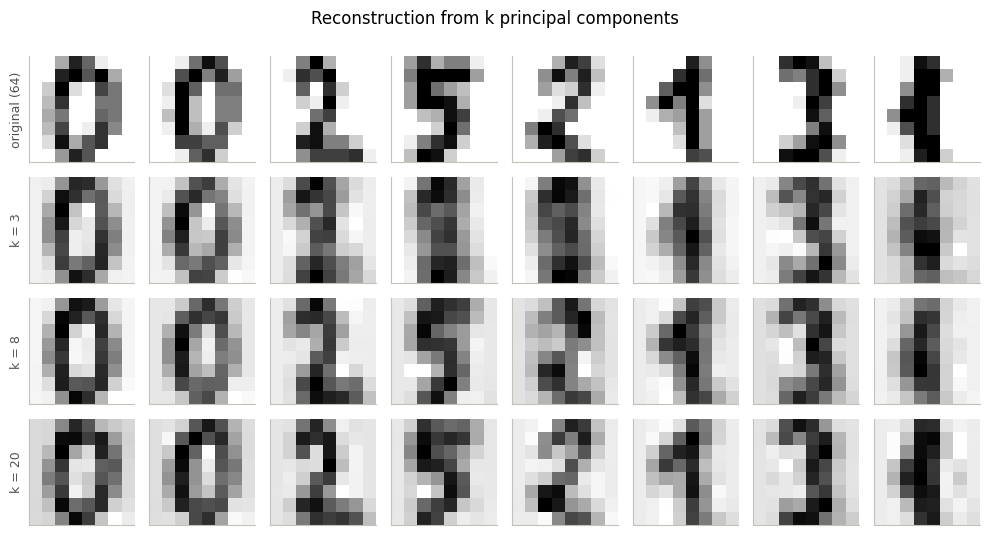

In [33]:
# Compression made visible: rebuild digit images from k components only.
fig, axes = plt.subplots(4, 8, figsize=(10, 5.4))
sample_idx = [0, 6, 14, 20, 30, 42, 55, 61]
for col, si in enumerate(sample_idx):
    axes[0, col].imshow(Xd64[si].reshape(8, 8), cmap="gray_r")
    for row, kc in enumerate([3, 8, 20], start=1):
        recon = Xc64[si] @ Vt[:kc].T @ Vt[:kc] + Xd64.mean(0)
        axes[row, col].imshow(recon.reshape(8, 8), cmap="gray_r")
for row, lab in enumerate(["original (64)", "k = 3", "k = 8", "k = 20"]):
    axes[row, 0].set_ylabel(lab, fontsize=9, color="#52514e")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Reconstruction from k principal components", y=0.99)
plt.tight_layout(); plt.show()

**Practice notes:** standardize features first when they're on different scales (otherwise PCA just
finds the biggest-unit feature); PCA is linear — for curved manifolds look at t-SNE or UMAP (great for
visualization, but *only* visualization: their distances aren't meaningful); and when PCA feeds a
supervised model, fit it inside the pipeline (leakage rule from section 11 applies — PCA is
data-dependent preprocessing!).

<a id="19"></a>
## 19. Diagnosing models: learning and validation curves

You've trained a model and the score is disappointing. **What do you do next — get more data, add
features, or simplify the model?** Guessing is expensive; two cheap plots answer it.

A **learning curve** (score vs training-set size) diagnoses bias vs variance:
- Curves converged, both low → **high bias**: more data won't help; add capacity/features.
- Big persistent gap → **high variance**: more data *will* help; so will regularization.

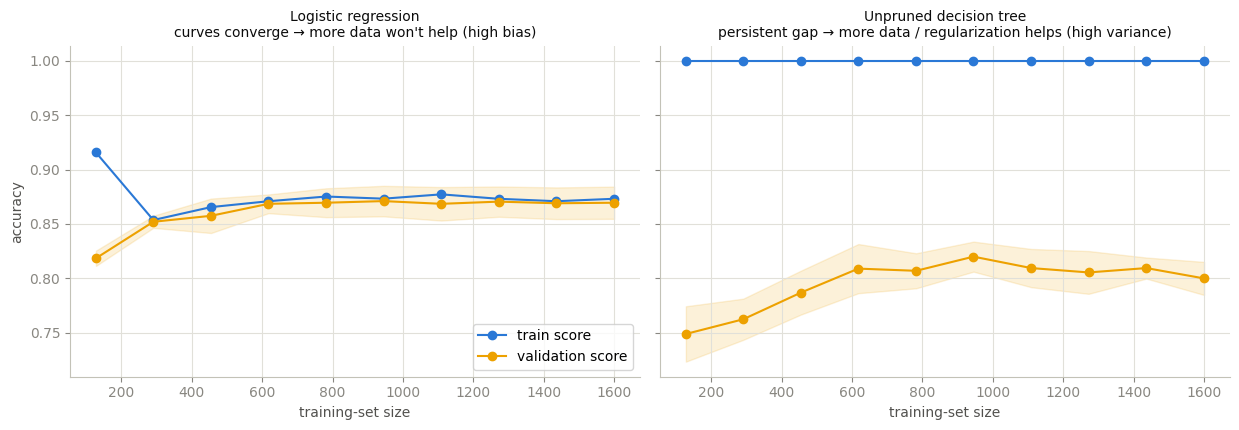

In [34]:
from sklearn.model_selection import learning_curve, validation_curve

Xlc, ylc = make_classification(n_samples=2000, n_features=20, n_informative=6,
                               flip_y=0.1, random_state=11)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, model, name, verdict in [
        (axes[0], LogisticRegression(max_iter=2000), "Logistic regression",
         "curves converge → more data won't help (high bias)"),
        (axes[1], DecisionTreeClassifier(random_state=0), "Unpruned decision tree",
         "persistent gap → more data / regularization helps (high variance)")]:
    sizes, tr, va = learning_curve(model, Xlc, ylc, cv=5,
                                   train_sizes=np.linspace(0.08, 1.0, 10), n_jobs=-1)
    ax.plot(sizes, tr.mean(1), "o-", color=PALETTE[0], label="train score")
    ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1),
                    color=PALETTE[2], alpha=0.15)
    ax.plot(sizes, va.mean(1), "o-", color=PALETTE[2], label="validation score")
    ax.set_title(f"{name}\n{verdict}", fontsize=10)
    ax.set_xlabel("training-set size")
axes[0].set_ylabel("accuracy"); axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

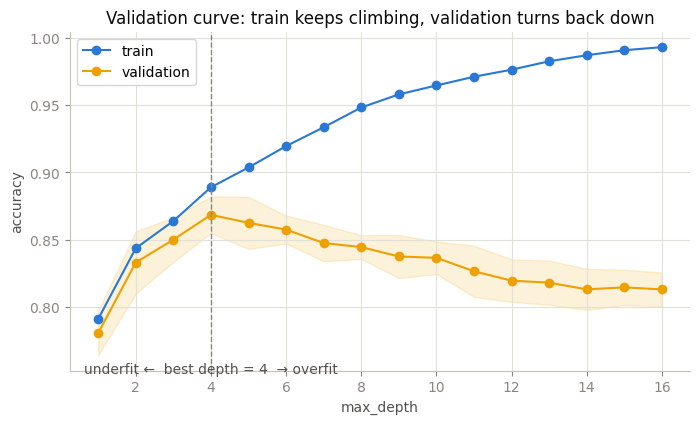

In [35]:
# A validation curve sweeps ONE hyperparameter and shows the U-shape of section 9 in the wild.
depths = np.arange(1, 17)
tr, va = validation_curve(DecisionTreeClassifier(random_state=0), Xlc, ylc,
                          param_name="max_depth", param_range=depths, cv=5, n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(depths, tr.mean(1), "o-", color=PALETTE[0], label="train")
ax.fill_between(depths, va.mean(1) - va.std(1), va.mean(1) + va.std(1), color=PALETTE[2], alpha=0.15)
ax.plot(depths, va.mean(1), "o-", color=PALETTE[2], label="validation")
best_d = depths[np.argmax(va.mean(1))]
ax.axvline(best_d, color=GRAY, ls="--", lw=1)
ax.annotate(f"underfit ←  best depth = {best_d}  → overfit", (best_d, va.mean(1).min()),
            ha="center", xytext=(best_d, va.mean(1).min() - 0.03), color="#52514e", fontsize=10)
ax.set_xlabel("max_depth"); ax.set_ylabel("accuracy")
ax.set_title("Validation curve: train keeps climbing, validation turns back down")
ax.legend()
plt.show()

Read these two plots before touching any hyperparameter — they tell you which side of the U-curve you're
on, and therefore which interventions can possibly work. This habit separates practitioners who iterate
purposefully from those who churn through random ideas.

<a id="20"></a>
## 20. Hyperparameter tuning

Hyperparameters (tree depth, $C$, $\gamma$, learning rate…) are set *before* training, so we search over
them — always scoring by cross-validation, never the test set. Two classic strategies:

- **Grid search**: try every combination on a grid. Thorough but exponential in the number of knobs.
- **Random search**: sample combinations at random. Usually better with the same budget when only a few
  knobs actually matter (you get many more distinct values per knob).

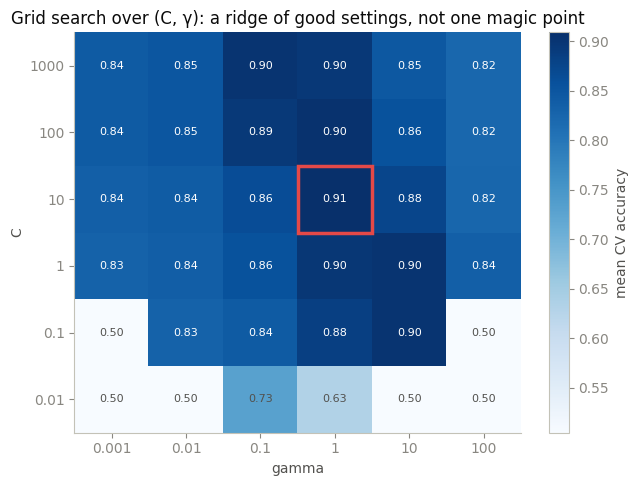

best params: {'svc__C': np.float64(10.0), 'svc__gamma': np.float64(1.0)}
best CV score:  0.909
test score:     0.900   <- the honest final number


In [36]:
from sklearn.model_selection import GridSearchCV

Xt, yt = make_moons(n_samples=600, noise=0.3, random_state=2)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.25, random_state=0)

Cs = np.logspace(-2, 3, 6)
gammas = np.logspace(-3, 2, 6)
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf")),
                    {"svc__C": Cs, "svc__gamma": gammas}, cv=5, n_jobs=-1)
grid.fit(Xt_tr, yt_tr)

scores_grid = grid.cv_results_["mean_test_score"].reshape(len(Cs), len(gammas))
fig, ax = plt.subplots(figsize=(7.2, 5.2))
im = ax.imshow(scores_grid, cmap="Blues", origin="lower", aspect="auto",
               vmin=scores_grid.min(), vmax=scores_grid.max())
ax.set_xticks(range(len(gammas)), [f"{g:g}" for g in gammas])
ax.set_yticks(range(len(Cs)), [f"{c:g}" for c in Cs])
ax.set_xlabel("gamma"); ax.set_ylabel("C"); ax.grid(False)
bi, bj = np.unravel_index(scores_grid.argmax(), scores_grid.shape)
ax.add_patch(plt.Rectangle((bj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor=PALETTE[5], lw=2.5))
for i in range(len(Cs)):
    for j in range(len(gammas)):
        dark = scores_grid[i, j] > scores_grid.min() + 0.7 * (scores_grid.max() - scores_grid.min())
        ax.text(j, i, f"{scores_grid[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if dark else "#52514e")
fig.colorbar(im, ax=ax, label="mean CV accuracy")
ax.set_title("Grid search over (C, γ): a ridge of good settings, not one magic point")
plt.show()

print(f"best params: {grid.best_params_}")
print(f"best CV score:  {grid.best_score_:.3f}")
print(f"test score:     {grid.score(Xt_te, yt_te):.3f}   <- the honest final number")

Three expert habits baked into that cell:
1. **The scaler lives inside the pipeline**, so each CV fold scales on its own training part — no leakage.
2. **Log-spaced grids** for scale-type parameters ($C$, $\gamma$, $\alpha$, learning rates).
3. The **test score is reported once, at the end** — `best_score_` is slightly optimistic because the
   search itself saw those folds (for a fully honest tuned-model estimate, use *nested* CV).

For bigger spaces, `RandomizedSearchCV` (same API, give distributions + a budget) or
`HalvingGridSearchCV` (successive halving: eliminate losers early on small data slices). Beyond sklearn,
Optuna/Bayesian optimization spend the budget adaptively. And keep perspective: **a better feature
usually beats a better hyperparameter.**

<a id="21"></a>
## 21. Imbalanced data and probability calibration

Fraud, churn, rare disease: often the interesting class is 1–5% of the data. Two traps await.

**Trap 1 — the accuracy mirage.** Predict "never fraud" and score 97% accuracy while catching nothing.
On imbalanced data, also prefer the **precision–recall curve** over ROC: ROC's false-positive rate uses
the giant negative class as its denominator, so ROC looks rosy even when precision is terrible.

positives in training data: 3.4%
plain logistic             accuracy=0.966  F1=0.000
class_weight='balanced'    accuracy=0.653  F1=0.122
predict-all-negative       accuracy=0.966  F1=0.000  <- the mirage


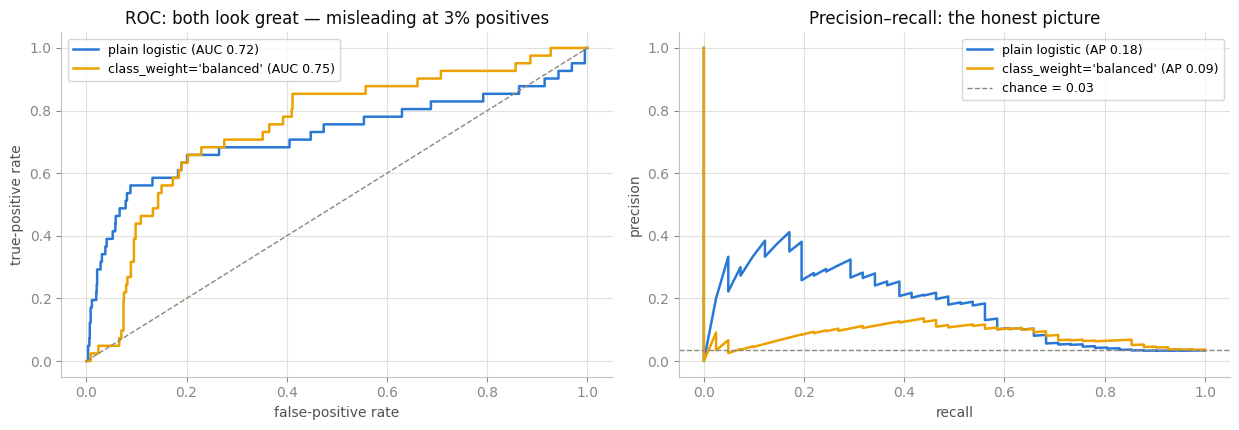

In [37]:
Ximb, yimb = make_classification(n_samples=4000, n_features=12, n_informative=5,
                                 weights=[0.97, 0.03], flip_y=0.01, random_state=13)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Ximb, yimb, test_size=0.3,
                                              random_state=0, stratify=yimb)
print(f"positives in training data: {yi_tr.mean():.1%}")

from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

models = {"plain logistic": LogisticRegression(max_iter=2000),
          "class_weight='balanced'": LogisticRegression(max_iter=2000, class_weight="balanced")}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
for (name, m), color in zip(models.items(), [PALETTE[0], PALETTE[2]]):
    m.fit(Xi_tr, yi_tr)
    s = m.predict_proba(Xi_te)[:, 1]
    fpr, tpr = roc_scratch(yi_te, s)
    p, r, _ = precision_recall_curve(yi_te, s)
    ax1.plot(fpr, tpr, color=color, lw=1.8,
             label=f"{name} (AUC {roc_auc_score(yi_te, s):.2f})")
    ax2.plot(r, p, color=color, lw=1.8,
             label=f"{name} (AP {average_precision_score(yi_te, s):.2f})")
    print(f"{name:26s} accuracy={ (m.predict(Xi_te)==yi_te).mean():.3f}  "
          f"F1={f1_score(yi_te, m.predict(Xi_te)):.3f}")
print(f"{'predict-all-negative':26s} accuracy={(yi_te==0).mean():.3f}  F1=0.000  <- the mirage")

ax1.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1)
ax1.set_xlabel("false-positive rate"); ax1.set_ylabel("true-positive rate")
ax1.set_title("ROC: both look great — misleading at 3% positives"); ax1.legend(fontsize=9)
ax2.axhline(yi_te.mean(), color=GRAY, ls="--", lw=1, label=f"chance = {yi_te.mean():.2f}")
ax2.set_xlabel("recall"); ax2.set_ylabel("precision")
ax2.set_title("Precision–recall: the honest picture"); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

Standard playbook for imbalance: **stratify** every split, evaluate with PR-AUC / F1 / recall-at-precision
(never plain accuracy), reweight errors (`class_weight="balanced"` — note above how it trades a little
accuracy for a much better F1), tune the decision threshold to your costs, and only then consider
resampling (e.g. SMOTE). Collecting more minority examples beats all of it.

**Trap 2 — uncalibrated confidence.** Downstream decisions often consume the *probability* ("call the
customer if churn risk > 30%"). A model is **calibrated** if events it gives probability $p$ happen a
fraction $p$ of the time. Check with a reliability diagram:

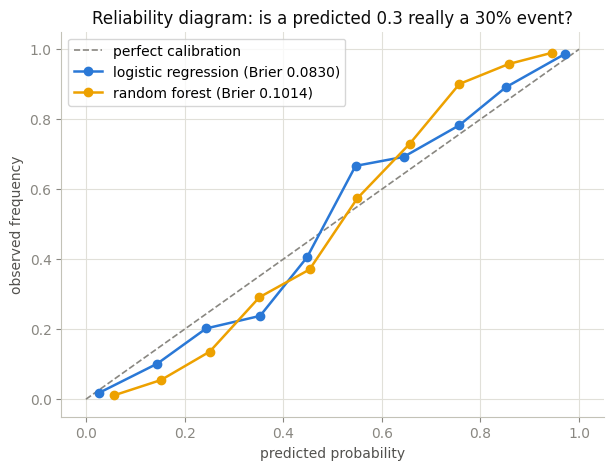

In [38]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Calibration is easiest to SEE on a balanced problem whose true labels really do come
# from a logistic model -- then we KNOW what the correct probabilities are.
Xcal = rng.normal(size=(4000, 8))
w_true = rng.normal(size=8)
ycal = (rng.random(4000) < sigmoid(Xcal @ w_true * 1.2)).astype(int)
Xcal_tr, Xcal_te, ycal_tr, ycal_te = train_test_split(Xcal, ycal, test_size=0.4, random_state=0)

lr_c = LogisticRegression(max_iter=2000).fit(Xcal_tr, ycal_tr)
rf_c = RandomForestClassifier(n_estimators=150, random_state=0, n_jobs=-1).fit(Xcal_tr, ycal_tr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1.2, label="perfect calibration")
for m, name, color in [(lr_c, "logistic regression", PALETTE[0]),
                       (rf_c, "random forest", PALETTE[2])]:
    s = m.predict_proba(Xcal_te)[:, 1]
    frac, mean_pred = calibration_curve(ycal_te, s, n_bins=10)
    ax.plot(mean_pred, frac, "o-", color=color, lw=1.8,
            label=f"{name} (Brier {brier_score_loss(ycal_te, s):.4f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_title("Reliability diagram: is a predicted 0.3 really a 30% event?")
ax.legend()
plt.show()

Logistic regression hugs the diagonal because log loss *directly rewards* calibrated probabilities
(and here it's also the true model family). The random forest traces the classic S-shape — too
confident at both extremes. Its votes separate the classes fine (good *discrimination*), but the vote
fractions are not honest probabilities (poor *calibration*): a predicted 0.9 comes true more like 96%
of the time, a predicted 0.15 more like 4%. When you need trustworthy probabilities from an uncalibrated
model, wrap it in `CalibratedClassifierCV` (isotonic or Platt/sigmoid scaling, fit on held-out folds) —
or use `FrozenEstimator` with a dedicated calibration set. The **Brier score** (mean squared error on
probabilities) is the single number that tracks both discrimination and calibration.

<a id="22"></a>
## 22. Capstone: an end-to-end project

Everything at once, the way real work flows: **frame → explore → split → preprocess (in a pipeline) →
compare models → tune → evaluate once → decide with costs**.

**The task:** a telecom has customer records and wants to know who is likely to churn, so the retention
team can intervene. We simulate a realistic dataset — mixed numeric/categorical features **with missing
values** — because clean data is a classroom fiction.

In [39]:
n = 2500
contract = rng.choice(["month-to-month", "one-year", "two-year"], n, p=[0.5, 0.3, 0.2])
tenure = np.clip(rng.gamma(2.0, 12.0, n), 1, 72).round()
monthly = np.clip(rng.normal(65, 20, n), 20, 120).round(2)
support_calls = rng.poisson(1.2, n)
payment = rng.choice(["card", "bank transfer", "e-check"], n, p=[0.4, 0.35, 0.25])

logit = (-1.8 + 1.1 * (contract == "month-to-month") - 0.035 * tenure
         + 0.012 * (monthly - 65) + 0.38 * support_calls + 0.55 * (payment == "e-check"))
churned = (rng.random(n) < sigmoid(logit)).astype(int)

churn = pd.DataFrame({"contract": contract, "tenure_months": tenure,
                      "monthly_charges": monthly,
                      "support_calls": support_calls.astype(float),
                      "payment_method": payment, "churned": churned})
# real data has holes -- punch some
churn.loc[rng.choice(n, n // 20, replace=False), "monthly_charges"] = np.nan
churn.loc[rng.choice(n, n // 25, replace=False), "payment_method"] = None

print(f"churn rate: {churn.churned.mean():.1%}   |   missing values per column:")
print(churn.isna().sum().to_string())
churn.head()

churn rate: 23.0%   |   missing values per column:
contract             0
tenure_months        0
monthly_charges    125
support_calls        0
payment_method     100
churned              0


,contract,tenure_months,monthly_charges,support_calls,payment_method,churned
0,two-year,40.0,104.64,1.0,card,0
1,month-to-month,37.0,89.44,0.0,card,0
2,month-to-month,52.0,98.25,0.0,e-check,1
3,one-year,37.0,93.96,4.0,e-check,0
4,month-to-month,9.0,54.22,1.0,bank transfer,1


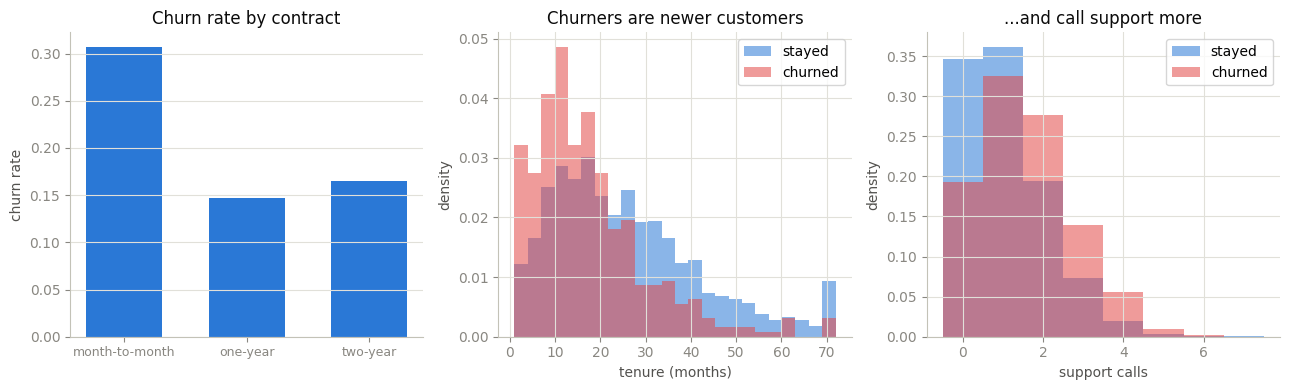

In [40]:
# --- Explore (on the TRAINING split only -- EDA is data-dependent too!)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(churn, test_size=0.25, random_state=0,
                                     stratify=churn.churned)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
by_contract = train_df.groupby("contract", observed=True).churned.mean().reindex(
    ["month-to-month", "one-year", "two-year"])
axes[0].bar(by_contract.index, by_contract.values, color=PALETTE[0], width=0.62)
axes[0].set_ylabel("churn rate"); axes[0].set_title("Churn rate by contract")
axes[0].tick_params(axis="x", labelsize=9); axes[0].grid(axis="x", visible=False)

for lab, color in [(0, PALETTE[0]), (1, PALETTE[5])]:
    sub = train_df[train_df.churned == lab]
    axes[1].hist(sub.tenure_months, bins=24, alpha=0.55, color=color, density=True,
                 label=["stayed", "churned"][lab])
    axes[2].hist(sub.support_calls, bins=np.arange(0, 9) - 0.5, alpha=0.55, color=color,
                 density=True, label=["stayed", "churned"][lab])
axes[1].set_xlabel("tenure (months)"); axes[1].set_title("Churners are newer customers")
axes[2].set_xlabel("support calls"); axes[2].set_title("...and call support more")
axes[1].legend(); axes[2].legend()
for a in axes[1:]:
    a.set_ylabel("density")
plt.tight_layout(); plt.show()

In [41]:
# --- Preprocess + compare models, all inside pipelines, all by cross-validation.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate

num_cols = ["tenure_months", "monthly_charges", "support_calls"]
cat_cols = ["contract", "payment_method"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]), cat_cols),
])

X_train, y_train = train_df.drop(columns="churned"), train_df.churned
X_test, y_test = test_df.drop(columns="churned"), test_df.churned

candidates = {
    "logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "hist gradient boosting": HistGradientBoostingClassifier(random_state=0),
}

rows = []
for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=["roc_auc", "f1"], n_jobs=-1)
    rows.append({"model": name,
                 "ROC-AUC": f"{cv['test_roc_auc'].mean():.3f} ± {cv['test_roc_auc'].std():.3f}",
                 "F1": f"{cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}"})
pd.DataFrame(rows).set_index("model")

,ROC-AUC,F1
model,,
logistic regression,0.738 ± 0.026,0.483 ± 0.031
random forest,0.662 ± 0.024,0.315 ± 0.019
hist gradient boosting,0.682 ± 0.037,0.330 ± 0.018


best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 7, 'learning_rate': 0.03, 'l2_regularization': 1.0}
tuned CV ROC-AUC: 0.721
TEST  ROC-AUC: 0.695


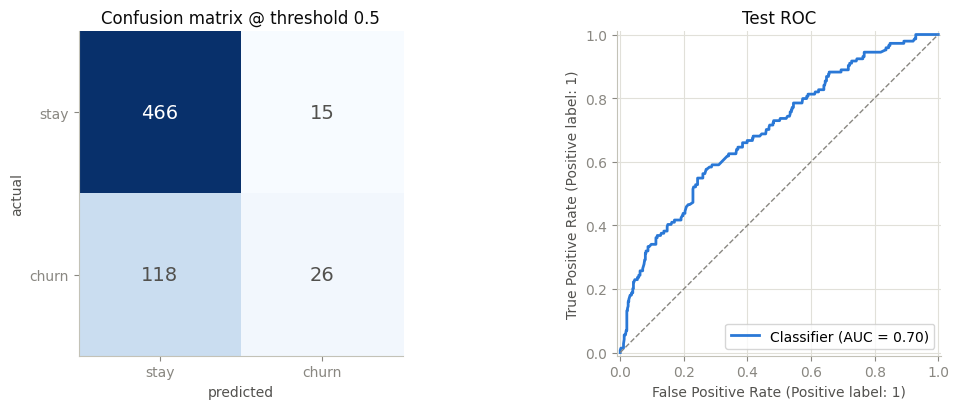

In [42]:
# --- Tune the leader, then evaluate ONCE on the untouched test set.
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, RocCurveDisplay

search = RandomizedSearchCV(
    Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(random_state=0))]),
    {"model__learning_rate": [0.03, 0.06, 0.1, 0.2],
     "model__max_leaf_nodes": [7, 15, 31, 63],
     "model__min_samples_leaf": [10, 20, 40],
     "model__l2_regularization": [0.0, 0.1, 1.0]},
    n_iter=20, cv=5, scoring="roc_auc", random_state=0, n_jobs=-1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print("best params:", {k.replace("model__", ""): v for k, v in search.best_params_.items()})
print(f"tuned CV ROC-AUC: {search.best_score_:.3f}")

proba_test = final_model.predict_proba(X_test)[:, 1]
print(f"TEST  ROC-AUC: {roc_auc_score(y_test, proba_test):.3f}")

cm = confusion_matrix(y_test, proba_test >= 0.5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = ax1.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=14,
                 color="white" if cm[i, j] > cm.max() * 0.6 else "#52514e")
ax1.set_xticks([0, 1], ["stay", "churn"]); ax1.set_yticks([0, 1], ["stay", "churn"])
ax1.set_xlabel("predicted"); ax1.set_ylabel("actual"); ax1.grid(False)
ax1.set_title("Confusion matrix @ threshold 0.5")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=ax2,
                                 curve_kwargs=dict(color=PALETTE[0], lw=2))
ax2.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1)
ax2.set_title("Test ROC")
plt.tight_layout(); plt.show()

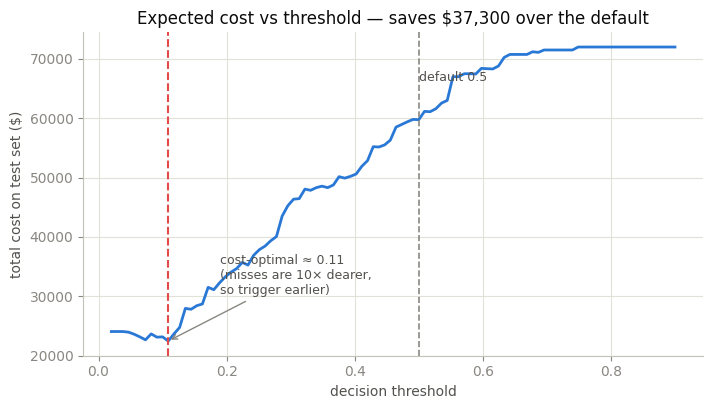

In [43]:
# --- The threshold is a business decision (section 10). Attach real costs:
#     a churned customer we missed costs $500 in lost value;
#     a retention offer sent to a false alarm costs $50.
COST_FN, COST_FP = 500, 50
ths = np.linspace(0.02, 0.9, 100)
costs = [(COST_FN * ((y_test == 1) & (proba_test < t)).sum()
          + COST_FP * ((y_test == 0) & (proba_test >= t)).sum()) for t in ths]
best_t = ths[int(np.argmin(costs))]
saved = costs[int(np.searchsorted(ths, 0.5))] - min(costs)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ths, costs, color=PALETTE[0], lw=2)
ax.axvline(0.5, color=GRAY, ls="--", lw=1.2)
ax.annotate("default 0.5", (0.5, max(costs) * 0.92), color="#52514e", fontsize=9, ha="left")
ax.axvline(best_t, color=PALETTE[5], ls="--", lw=1.5)
ax.annotate(f"cost-optimal ≈ {best_t:.2f}\n(misses are 10× dearer,\nso trigger earlier)",
            (best_t, min(costs)), xytext=(best_t + 0.08, min(costs) * 1.35),
            color="#52514e", fontsize=9, arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_xlabel("decision threshold"); ax.set_ylabel("total cost on test set ($)")
ax.set_title(f"Expected cost vs threshold — saves ${saved:,.0f} over the default")
plt.show()

**The complete workflow, as a checklist:**

1. **Frame**: what decision does the model power? What's the cost of each error type?
2. **Split first**, stratified; lock the test set away.
3. **Explore** the training data; note leakage risks and missing-value patterns.
4. **Preprocess inside a `Pipeline`/`ColumnTransformer`** — imputation, scaling, encoding.
5. **Compare model families** with cross-validation; start simple (a linear baseline earns its keep).
6. **Tune** the leader with randomized/grid search on CV.
7. **Evaluate once** on the test set — that number is what you report.
8. **Set the threshold from costs**, not habit. Ship, then monitor for drift.

(In production you'd also want: a dumb baseline in the report, model versioning, and monitoring —
input distributions drift, and models rot silently.)

<a id="23"></a>
## 23. Model interpretation

"It predicts well" is rarely enough — you'll be asked *why*. Two model-agnostic tools cover most needs:

- **Permutation importance**: shuffle one feature's column in the held-out data and measure how much the
  score drops. Breaks the feature–target relationship while keeping its distribution. (Unlike the
  forest's built-in impurity importance, it's computed on *held-out* data and isn't biased toward
  high-cardinality features.)
- **Partial dependence**: sweep one feature across its range, average the model's predictions over the
  data, and plot the curve — *how* does the feature move the prediction, not just how much.

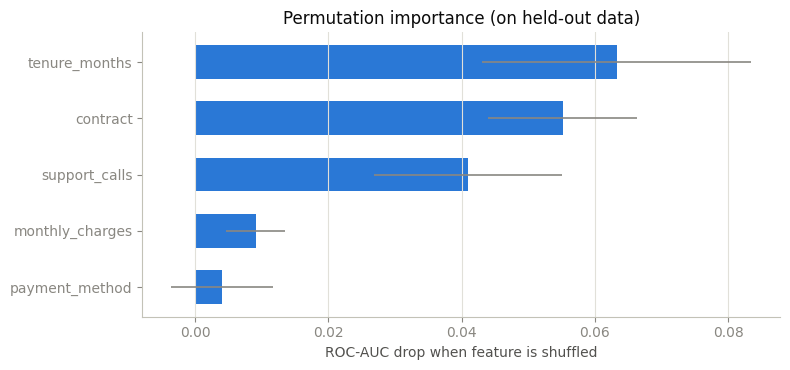

In [44]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

pi = permutation_importance(final_model, X_test, y_test, scoring="roc_auc",
                            n_repeats=15, random_state=0, n_jobs=-1)
order = np.argsort(pi.importances_mean)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(np.array(X_test.columns)[order], pi.importances_mean[order],
        xerr=pi.importances_std[order], color=PALETTE[0], height=0.6,
        error_kw=dict(ecolor=GRAY, lw=1.2))
ax.set_xlabel("ROC-AUC drop when feature is shuffled")
ax.set_title("Permutation importance (on held-out data)")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

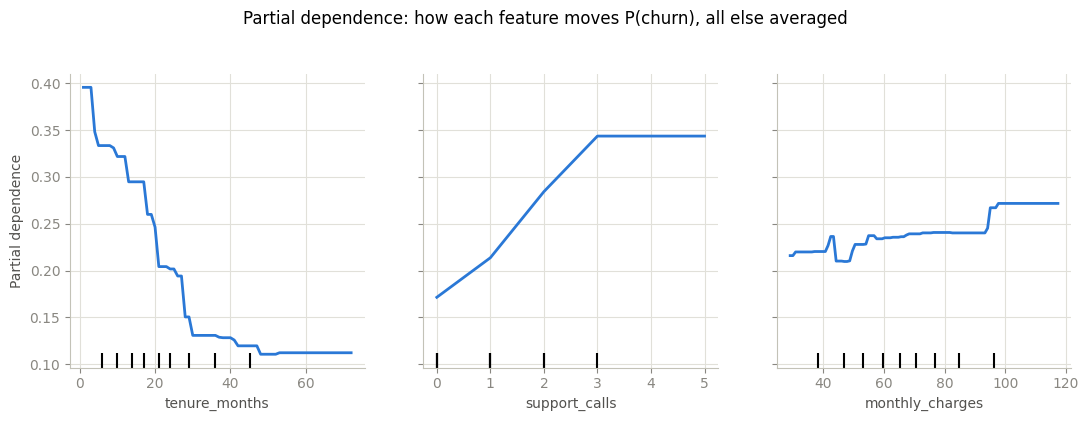

In [45]:
fig, ax = plt.subplots(figsize=(11, 4))
PartialDependenceDisplay.from_estimator(
    final_model, X_test, features=["tenure_months", "support_calls", "monthly_charges"],
    ax=ax, line_kw={"color": PALETTE[0], "lw": 2})
fig.suptitle("Partial dependence: how each feature moves P(churn), all else averaged", y=1.04)
plt.tight_layout(); plt.show()

The model rediscovered the world we simulated: churn risk *falls* with tenure and *rises* with support
calls — with the shapes, not just the signs. That's the kind of statement stakeholders can act on.

Going deeper: **SHAP values** explain *individual* predictions (why did *this* customer get 0.83?) with
solid game-theoretic footing. Caution for all of these: importance ≠ causation, and correlated features
share/steal credit — permuting one while its twin stays put creates impossible data points.

<a id="24"></a>
## 24. Where to go from here

### The one-table summary

| Model | Flexibility knob | Strengths | Watch out for |
|---|---|---|---|
| k-NN | k ↓ | zero training, local structure | scaling, slow at predict, high-D |
| Linear / logistic regression | (features), α ↑ regularizes | fast, calibrated, interpretable | only linear boundaries |
| Ridge / lasso | α | stability; lasso selects features | standardize first |
| Decision tree | depth ↑ | interpretable, no scaling, interactions | high variance alone |
| Random forest | (robust by design) | great tabular default, OOB score | memory, no extrapolation |
| Gradient boosting | rounds × learning rate ↑ | state of the art on tabular | overfits if unwatched — early-stop |
| SVM (RBF) | C ↑, γ ↑ | strong on small/medium clean data | O(n²), scaling, tuning |
| Neural network | width/depth ↑ | unstructured data, learns features | data-hungry, non-convex |
| k-means | k | fast, simple | round clusters, scaling, local optima |
| PCA | components ↓ | compression, decorrelation, viz | linear only; fit inside pipeline |

### The ideas that transfer everywhere

1. **Generalization is the goal**; training performance is a means, and often a lie (§2, 11).
2. **Every model has a flexibility knob**, and the U-curve (§9) tells you which way to turn it (§19).
3. **All preprocessing lives inside the pipeline** — leakage is the field's most common silent bug (§11).
4. **Averaging beats variance** (§13); **sequential correction beats bias** (§14).
5. **Metrics are decisions**: pick them from costs, thresholds included (§10, 21, 22).
6. Optimization is **gradient descent on a surrogate loss** almost everywhere you look (§4, 6, 14, 16).

### Continuing in this series

- `numpy_basics_to_expert.ipynb` / `pandas_basics_to_expert.ipynb` — the data layer under everything here
- `sklearn_basics_to_expert.ipynb` — the library this notebook kept "checking answers" against
- `pytorch_basics_to_expert.ipynb` — section 16, industrialized: autodiff, GPUs, deep architectures
- `opencv_basics_to_expert.ipynb` — classical computer vision

### Beyond this notebook

Deep learning (CNNs, transformers, LLMs) · time series & forecasting · causal inference (when you need
*why*, not *what*) · MLOps (deployment, monitoring, drift) · fairness and privacy. Classic references:
*An Introduction to Statistical Learning* (free PDF), *The Elements of Statistical Learning*,
and Kaggle for deliberate practice.

**You now know the actual machinery** — every method here was built from raw NumPy before we trusted a
library with it. That's the expert's advantage: libraries change, the math doesn't.